In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read data from Excel file
# Loading the dataset - sheet_name parameter is used if there are multiple tabs in the excel file.
from google.colab import drive
drive.mount('/content/drive/') #/Colab_notebooks/Python_Files

Mounted at /content/drive/


#Read the data from the '.csv' file as a monthly Time Series.

In [2]:
sparkling = pd.read_csv("/content/drive/My Drive/Colab_Notebooks/Sparkling.csv")
sparkling.head()

,YearMonth,Sparkling
0,1980-01,1686
1,1980-02,1591
2,1980-03,2304
3,1980-04,1712
4,1980-05,1471


In [3]:
df1= sparkling.copy()

In [4]:
# located my last value
df1.iloc[-1]

,186
YearMonth,1995-07
Sparkling,2031


#Creating the Time Stamps and adding to the data frame to make it a Time Series Data

In [5]:
date = pd.date_range(start='1/1/1980', end='8/1/1995', freq='M')
date

<ipython-input-5-fc7060c10332>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start='1/1/1980', end='8/1/1995', freq='M')


DatetimeIndex(['1980-01-31', '1980-02-29', '1980-03-31', '1980-04-30',
               '1980-05-31', '1980-06-30', '1980-07-31', '1980-08-31',
               '1980-09-30', '1980-10-31',
               ...
               '1994-10-31', '1994-11-30', '1994-12-31', '1995-01-31',
               '1995-02-28', '1995-03-31', '1995-04-30', '1995-05-31',
               '1995-06-30', '1995-07-31'],
              dtype='datetime64[ns]', length=187, freq='ME')

In [6]:
# Adding the time stamp to the data frame
df1['Time_Stamp'] = pd.DataFrame(date)
df1.head()

,YearMonth,Sparkling,Time_Stamp
0,1980-01,1686,1980-01-31
1,1980-02,1591,1980-02-29
2,1980-03,2304,1980-03-31
3,1980-04,1712,1980-04-30
4,1980-05,1471,1980-05-31


In [7]:
df1.set_index('Time_Stamp',inplace=True)
df1.head()

,YearMonth,Sparkling
Time_Stamp,,
1980-01-31,1980-01,1686
1980-02-29,1980-02,1591
1980-03-31,1980-03,2304
1980-04-30,1980-04,1712
1980-05-31,1980-05,1471


In [8]:
df1.drop('YearMonth',axis=1, inplace= True)
df1.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


#Plot the Time Series to understand the behaviour of the data.


In [9]:
# The following code is to set the subsequent figure sizes

from pylab import rcParams
rcParams['figure.figsize'] = 15,8

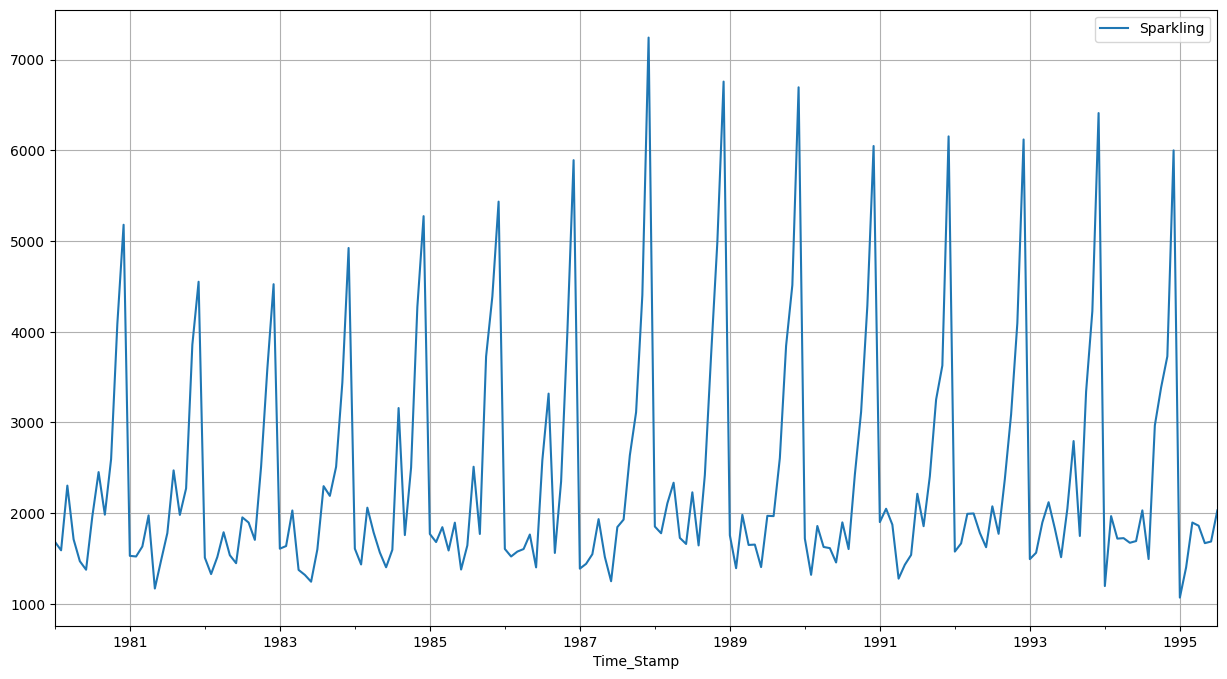

In [10]:
df1.plot()
plt.grid();

#Check the basic measures of descriptive statistics

In [11]:
df1.describe()

,Sparkling
count,187.000000
mean,2402.417112
std,1295.111540
min,1070.000000
25%,1605.000000
50%,1874.000000
75%,2549.000000
max,7242.000000


#Plot a boxplot to understand the spread of sales across different years and within different months across years.

##Yearly Boxplot

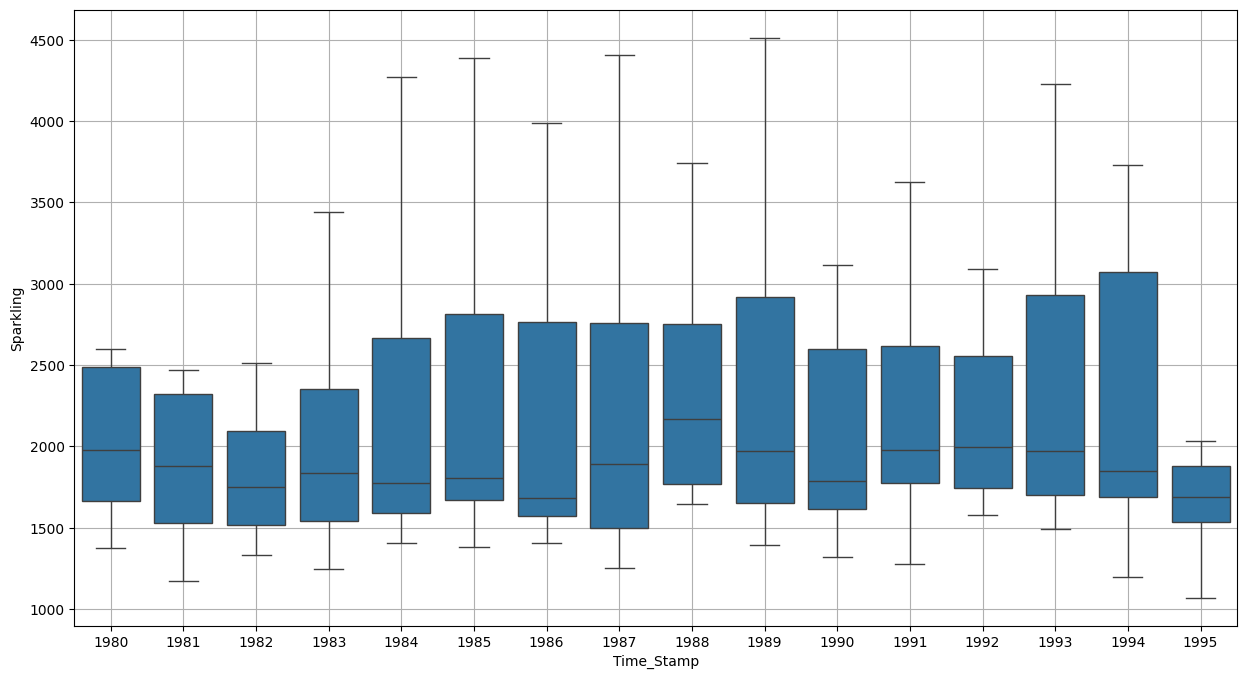

In [12]:
sns.boxplot(x = df1.index.year,y = df1['Sparkling'],showfliers=False)
plt.grid();

##Monthly Plot

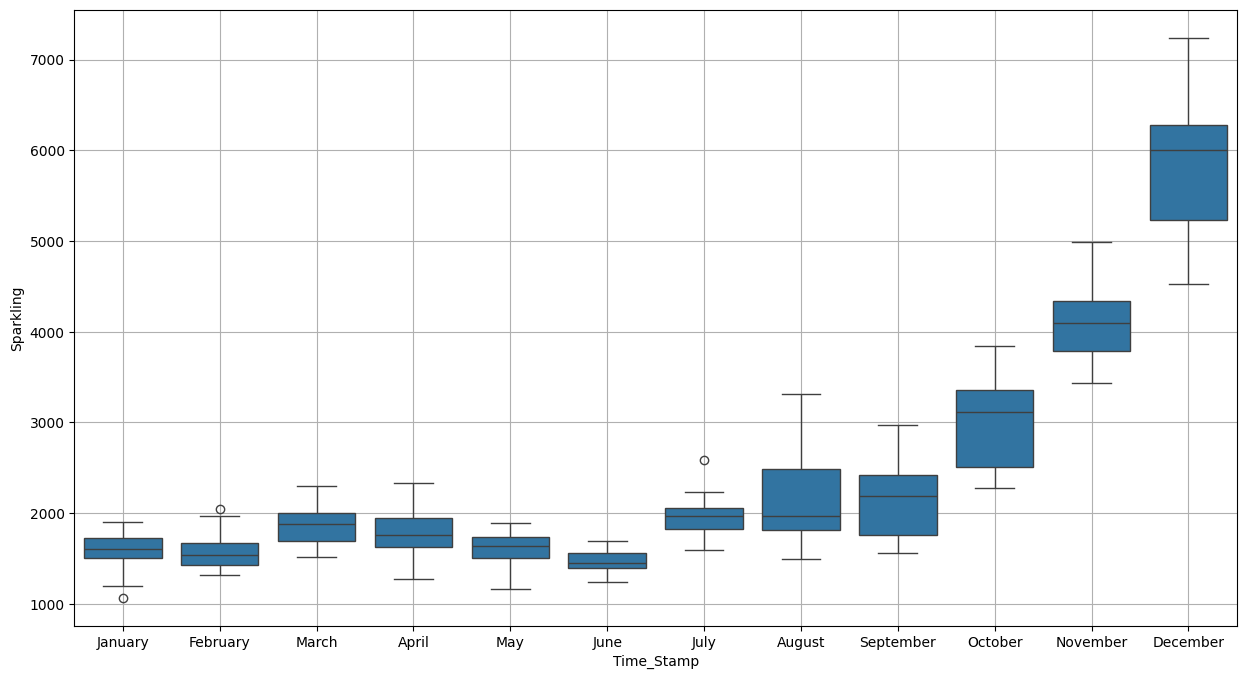

In [13]:
sns.boxplot(x = df1.index.month_name(),y = df1['Sparkling'])
plt.grid();

#Plot a time series monthplot to understand the spread of sales across different years and within different months across years.

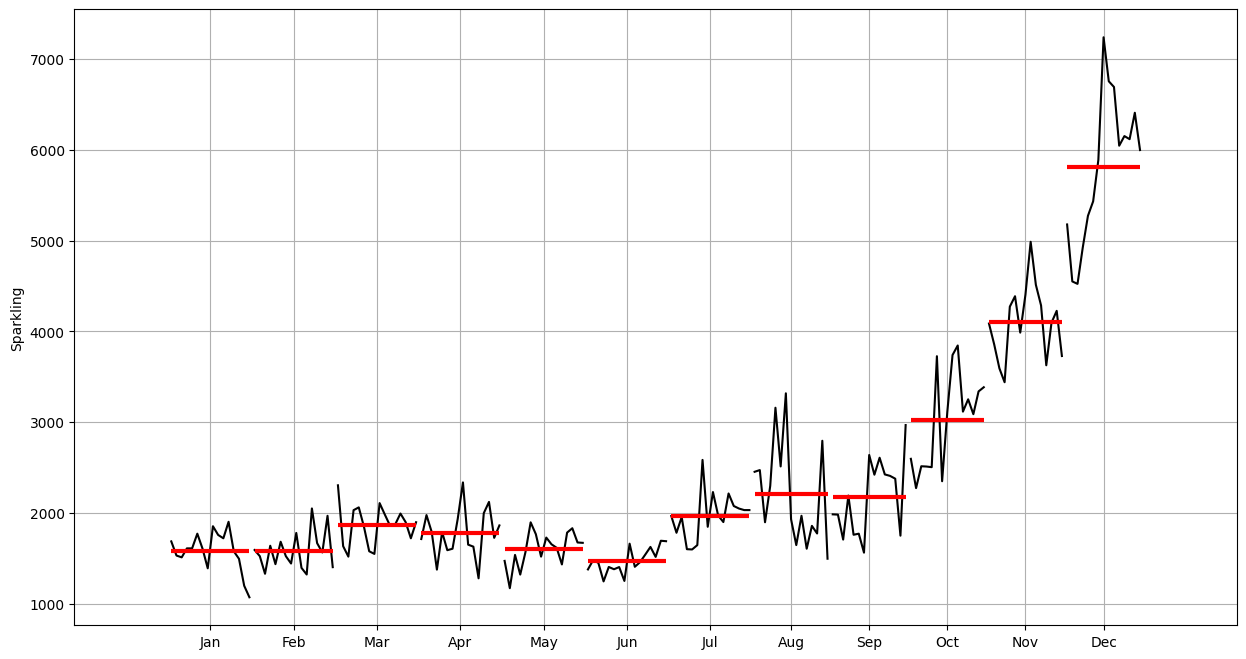

In [14]:
from statsmodels.graphics.tsaplots import month_plot

month_plot(df1['Sparkling'],ylabel='Sparkling')
plt.grid();

#Plot a graph of monthly Sparkling across years.

In [15]:
monthly_Sparkling_across_years = pd.pivot_table(df1, values = 'Sparkling', columns = df1.index.month, index = df1.index.year)
monthly_Sparkling_across_years

Time_Stamp,1,2,3,4,5,6,7,8,9,10,11,12
Time_Stamp,,,,,,,,,,,,
1980,1686.0,1591.0,2304.0,1712.0,1471.0,1377.0,1966.0,2453.0,1984.0,2596.0,4087.0,5179.0
1981,1530.0,1523.0,1633.0,1976.0,1170.0,1480.0,1781.0,2472.0,1981.0,2273.0,3857.0,4551.0
1982,1510.0,1329.0,1518.0,1790.0,1537.0,1449.0,1954.0,1897.0,1706.0,2514.0,3593.0,4524.0
1983,1609.0,1638.0,2030.0,1375.0,1320.0,1245.0,1600.0,2298.0,2191.0,2511.0,3440.0,4923.0
1984,1609.0,1435.0,2061.0,1789.0,1567.0,1404.0,1597.0,3159.0,1759.0,2504.0,4273.0,5274.0
1985,1771.0,1682.0,1846.0,1589.0,1896.0,1379.0,1645.0,2512.0,1771.0,3727.0,4388.0,5434.0
1986,1606.0,1523.0,1577.0,1605.0,1765.0,1403.0,2584.0,3318.0,1562.0,2349.0,3987.0,5891.0
1987,1389.0,1442.0,1548.0,1935.0,1518.0,1250.0,1847.0,1930.0,2638.0,3114.0,4405.0,7242.0
1988,1853.0,1779.0,2108.0,2336.0,1728.0,1661.0,2230.0,1645.0,2421.0,3740.0,4988.0,6757.0


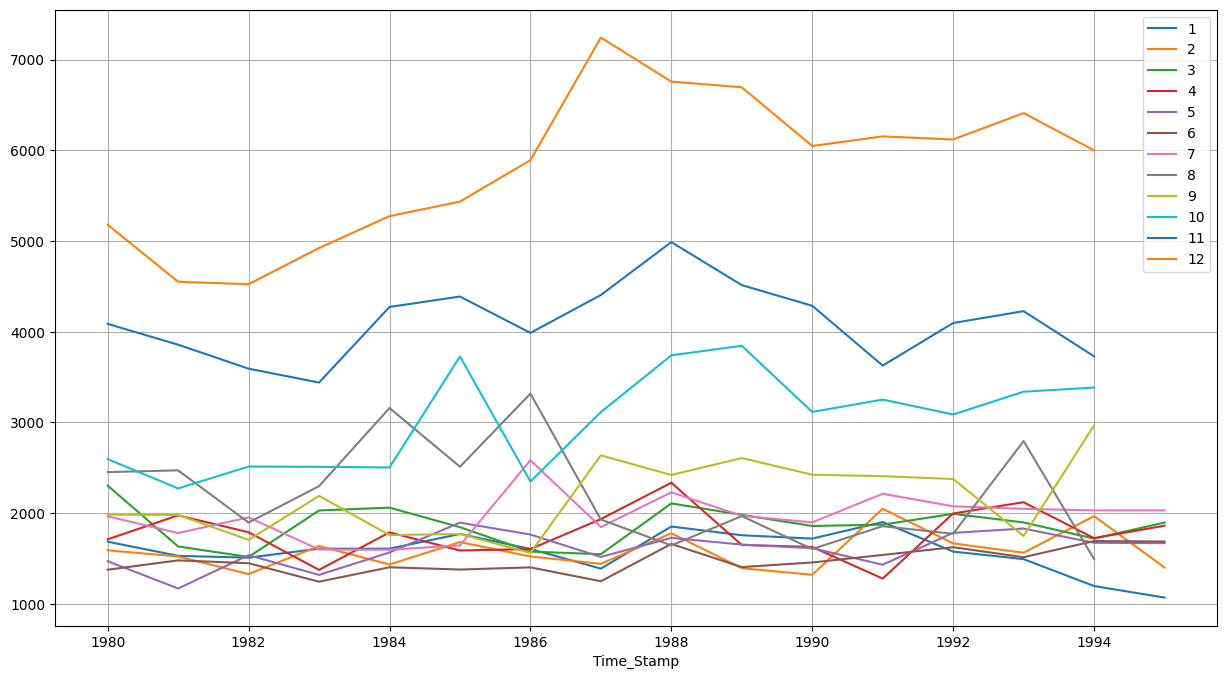

In [16]:
monthly_Sparkling_across_years.plot()
plt.grid()
plt.legend(loc='best');

#Plot the Empirical Cumulative Distribution.


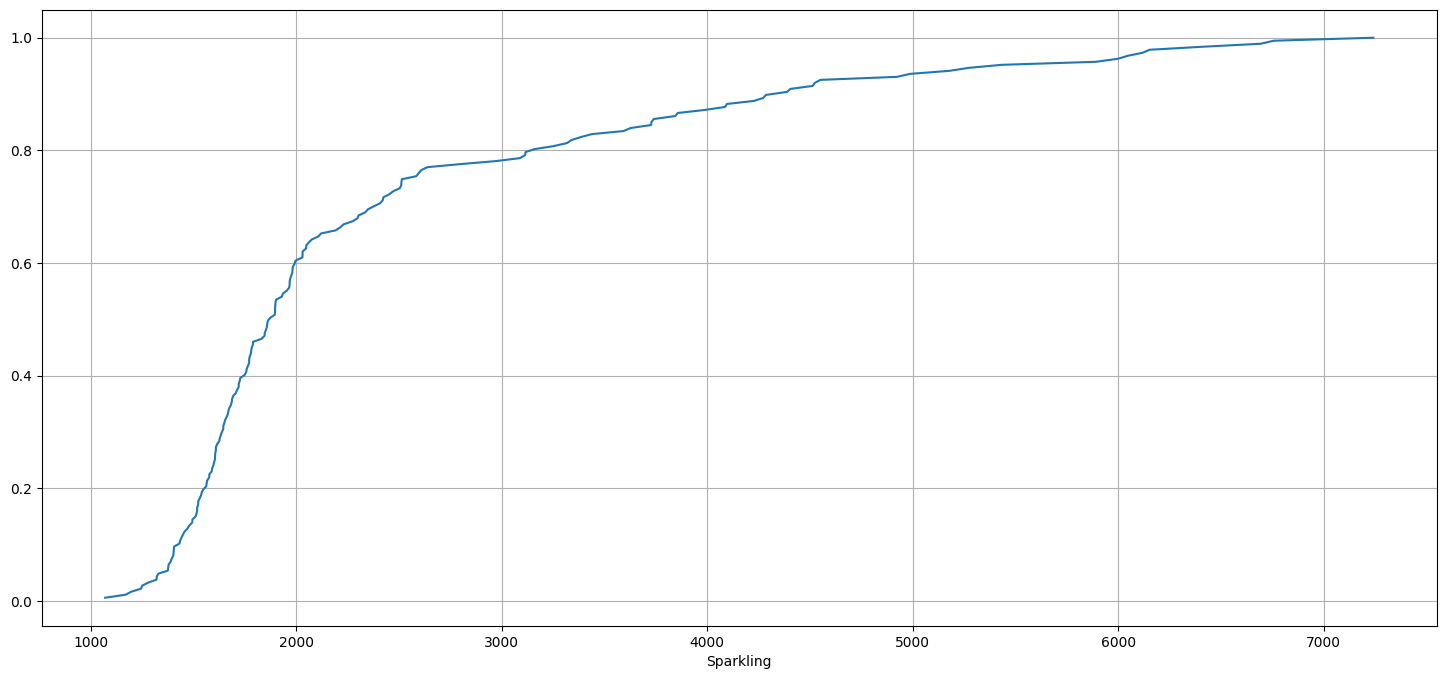

In [17]:
# statistics
from statsmodels.distributions.empirical_distribution import ECDF

plt.figure(figsize = (18, 8))
cdf = ECDF(df1['Sparkling'])
plt.plot(cdf.x, cdf.y, label = "statmodels");
plt.grid()
plt.xlabel('Sparkling');

#Plot the average RetailSales per month and the month on month percentage change of RetailSales.

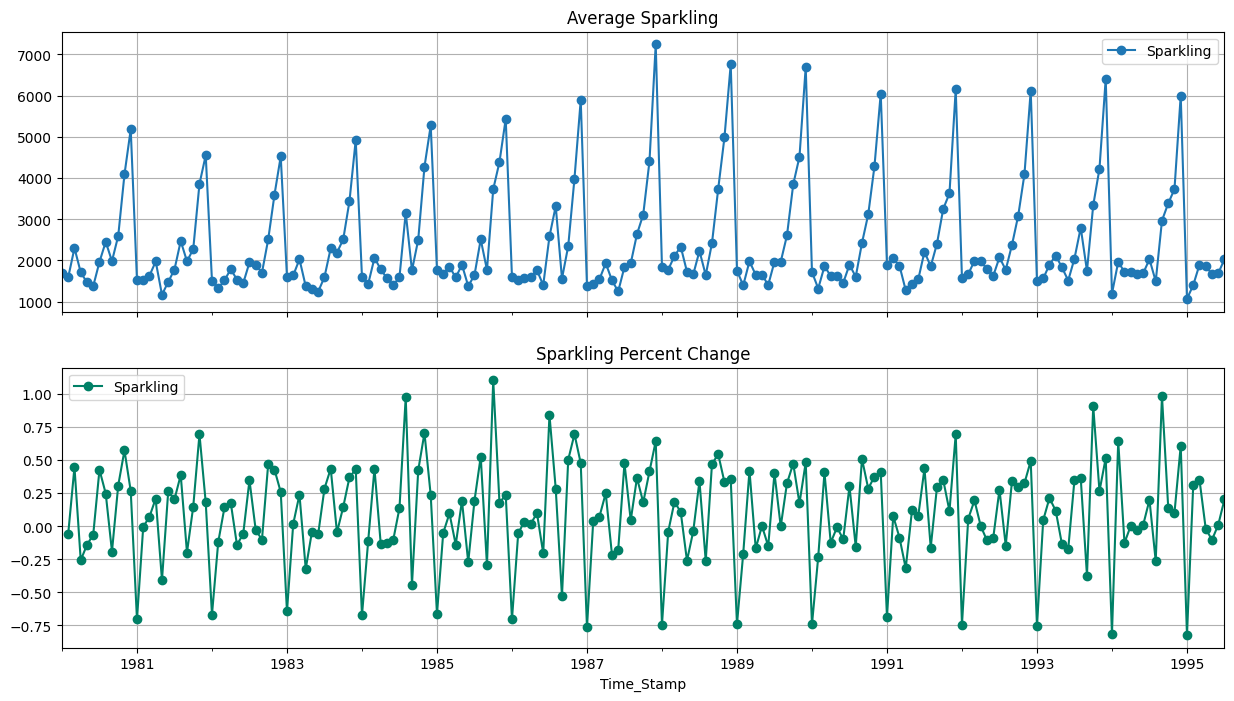

In [18]:
# group by date and get average Sparkling, and precent change
average    = df1.groupby(df1.index)["Sparkling"].mean()
pct_change = df1.groupby(df1.index)["Sparkling"].sum().pct_change()

fig, (axis1,axis2) = plt.subplots(2,1,sharex=True,figsize=(15,8))

# plot average Sparkling over time(year-month)
ax1 = average.plot(legend=True,ax=axis1,marker='o',title="Average Sparkling",grid=True)
ax1.set_xticks(range(len(average)))
ax1.set_xticklabels(average.index.tolist())
# plot precent change for Sparkling over time(year-month)
ax2 = pct_change.plot(legend=True,ax=axis2,marker='o',colormap="summer",title="Sparkling Percent Change",grid=True)

The above two graphs tells us the Average 'Sparkling' and the Percentage change of 'Sparkling' with respect to the time.

#Decompose the Time Series and plot the different components.

In [19]:
from    statsmodels.tsa.seasonal import   seasonal_decompose

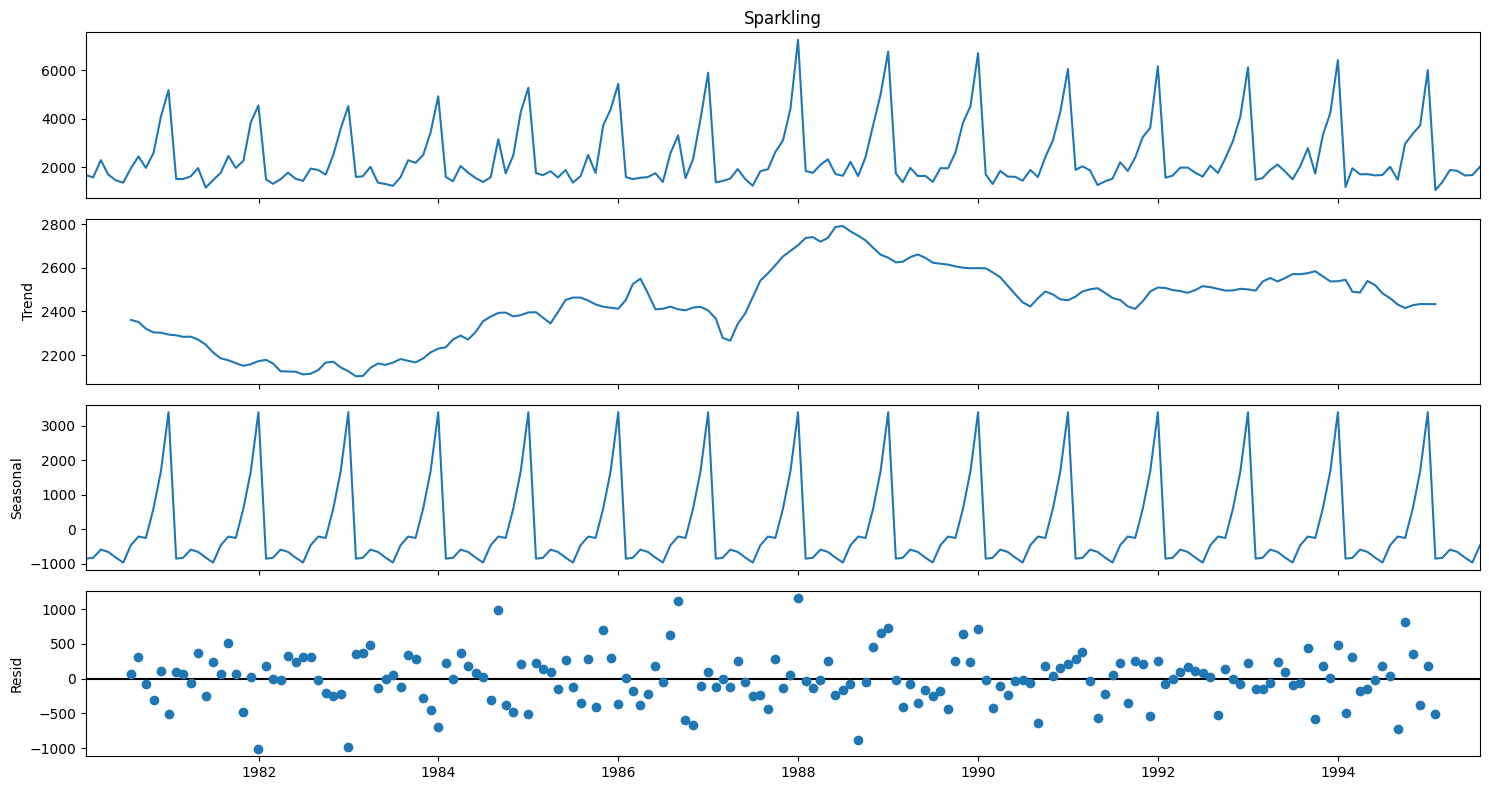

In [20]:
decomposition = seasonal_decompose(df1['Sparkling'],model='additive')
decomposition.plot();

We see that the residuals are located around 0 from the plot of the residuals in the decomposition.

In [21]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 Time_Stamp
1980-01-31            NaN
1980-02-29            NaN
1980-03-31            NaN
1980-04-30            NaN
1980-05-31            NaN
1980-06-30            NaN
1980-07-31    2360.666667
1980-08-31    2351.333333
1980-09-30    2320.541667
1980-10-31    2303.583333
1980-11-30    2302.041667
1980-12-31    2293.791667
Name: trend, dtype: float64 

Seasonality 
 Time_Stamp
1980-01-31    -854.260599
1980-02-29    -830.350678
1980-03-31    -592.356630
1980-04-30    -658.490559
1980-05-31    -824.416154
1980-06-30    -967.434011
1980-07-31    -465.502265
1980-08-31    -214.332821
1980-09-30    -254.677265
1980-10-31     599.769957
1980-11-30    1675.067179
1980-12-31    3386.983846
Name: seasonal, dtype: float64 

Residual 
 Time_Stamp
1980-01-31           NaN
1980-02-29           NaN
1980-03-31           NaN
1980-04-30           NaN
1980-05-31           NaN
1980-06-30           NaN
1980-07-31     70.835599
1980-08-31    315.999487
1980-09-30    -81.864401
1980-10-31   -307.3532

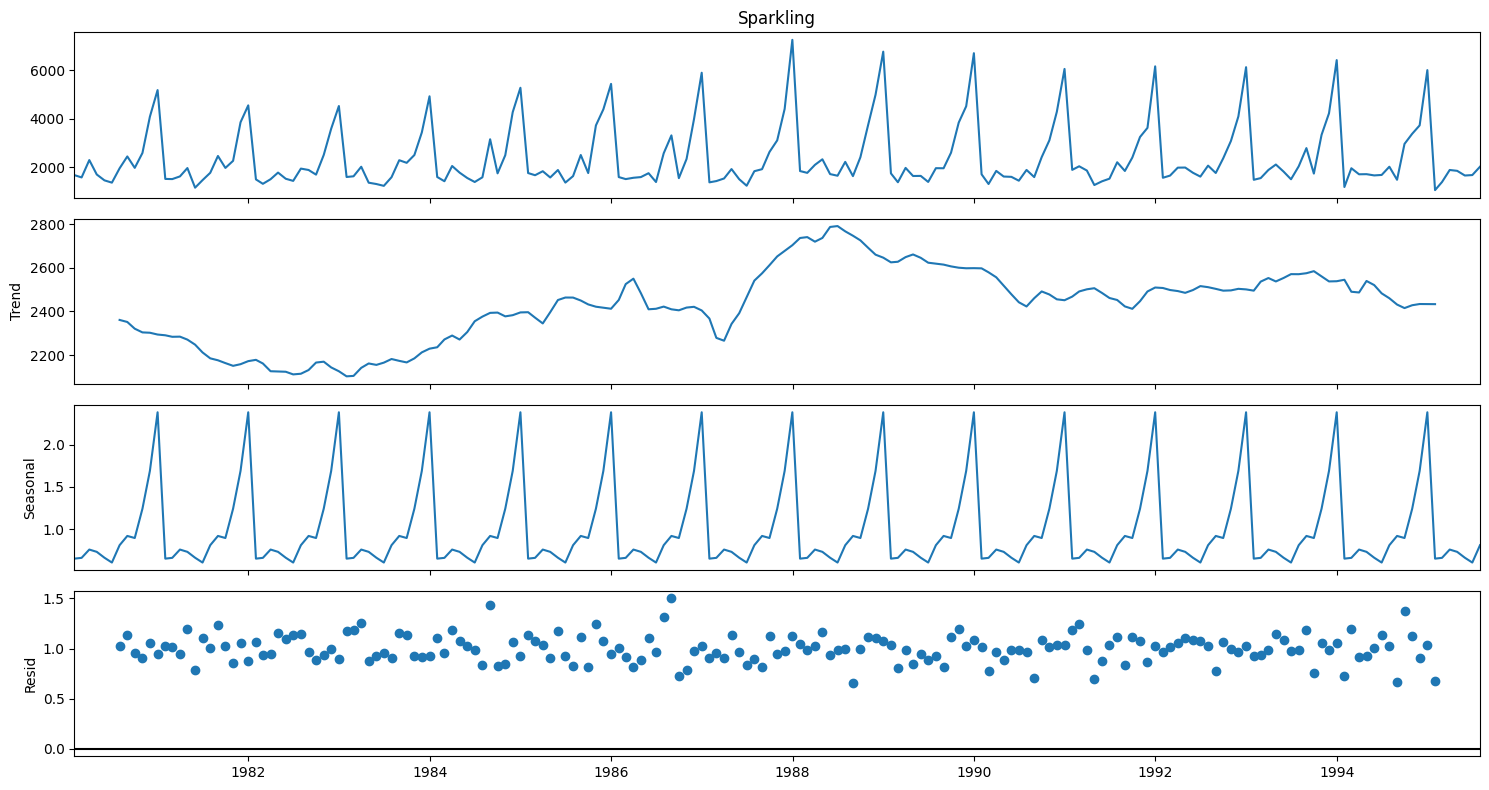

In [22]:
decomposition = seasonal_decompose(df1['Sparkling'],model='multiplicative')
decomposition.plot();

- For the multiplicative series, we see that a lot of residuals are located around 1. Thus Multiplicative Decomposition is the right way to decompose the time series

In [23]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 Time_Stamp
1980-01-31            NaN
1980-02-29            NaN
1980-03-31            NaN
1980-04-30            NaN
1980-05-31            NaN
1980-06-30            NaN
1980-07-31    2360.666667
1980-08-31    2351.333333
1980-09-30    2320.541667
1980-10-31    2303.583333
1980-11-30    2302.041667
1980-12-31    2293.791667
Name: trend, dtype: float64 

Seasonality 
 Time_Stamp
1980-01-31    0.649843
1980-02-29    0.659214
1980-03-31    0.757440
1980-04-30    0.730351
1980-05-31    0.660609
1980-06-30    0.603468
1980-07-31    0.809164
1980-08-31    0.918822
1980-09-30    0.894367
1980-10-31    1.241789
1980-11-30    1.690158
1980-12-31    2.384776
Name: seasonal, dtype: float64 

Residual 
 Time_Stamp
1980-01-31         NaN
1980-02-29         NaN
1980-03-31         NaN
1980-04-30         NaN
1980-05-31         NaN
1980-06-30         NaN
1980-07-31    1.029230
1980-08-31    1.135407
1980-09-30    0.955954
1980-10-31    0.907513
1980-11-30    1.050423
1980-12-31    0.946770
Name: r

#Split the data into train and test and plot the training and test data.

In [24]:
train    =   df1[0:int(len(df1)*0.7)]
test     =   df1[int(len(df1)*0.7):]

In [25]:
print(train.shape)
print(test.shape)

(130, 1)
(57, 1)


In [26]:
test['Sparkling'].unique()

array([4286, 6047, 1902, 2049, 1874, 1279, 1432, 1540, 2214, 1857, 2408,
       3252, 3627, 6153, 1577, 1667, 1993, 1997, 1783, 1625, 2076, 1773,
       2377, 3088, 4096, 6119, 1494, 1564, 1898, 2121, 1831, 1515, 2048,
       2795, 1749, 3339, 4227, 6410, 1197, 1968, 1720, 1725, 1674, 1693,
       2031, 1495, 2968, 3385, 3729, 5999, 1070, 1402, 1897, 1862, 1670,
       1688])

In [27]:
test.isna().sum()

,0
Sparkling,0


In [28]:
print('First few rows of Training Data','\n',train.head(),'\n')
print('Last few rows of Training Data','\n',train.tail(),'\n')
print('First few rows of Test Data','\n',test.head(),'\n')
print('Last few rows of Test Data','\n',test.tail(),'\n')

First few rows of Training Data 
             Sparkling
Time_Stamp           
1980-01-31       1686
1980-02-29       1591
1980-03-31       2304
1980-04-30       1712
1980-05-31       1471 

Last few rows of Training Data 
             Sparkling
Time_Stamp           
1990-06-30       1457
1990-07-31       1899
1990-08-31       1605
1990-09-30       2424
1990-10-31       3116 

First few rows of Test Data 
             Sparkling
Time_Stamp           
1990-11-30       4286
1990-12-31       6047
1991-01-31       1902
1991-02-28       2049
1991-03-31       1874 

Last few rows of Test Data 
             Sparkling
Time_Stamp           
1995-03-31       1897
1995-04-30       1862
1995-05-31       1670
1995-06-30       1688
1995-07-31       2031 



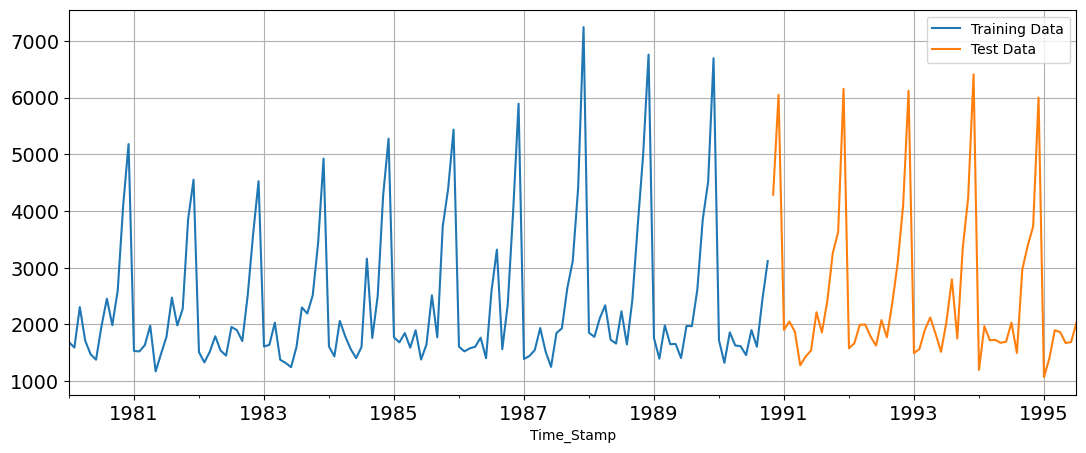

In [29]:
train['Sparkling'].plot(figsize=(13,5), fontsize=14)
test['Sparkling'].plot(figsize=(13,5), fontsize=14)
plt.grid()
plt.legend(['Training Data','Test Data'])
plt.show()

Note: It is difficult to predict the future observations if such an instance has not happened in the past. From our train-test split we are predicting likewise behaviour as compared to the past years.

# Building different models and comparing the accuracy metrics.

## Model 1: Linear Regression

For this particular linear regression, we are going to regress the 'Sparkling' variable against the order of the occurrence. For this we need to modify our training data before fitting it into a linear regression.

In [30]:
train_time = [i+1 for i in range(len(train))]
test_time = [i+43 for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]
Test Time instance 
 [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


We see that we have successfully the generated the numerical time instance order for both the training and test set. Now we will add these values in the training and test set.

In [31]:
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [32]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data','\n',LinearRegression_train.head(),'\n')
print('Last few rows of Training Data','\n',LinearRegression_train.tail(),'\n')
print('First few rows of Test Data','\n',LinearRegression_test.head(),'\n')
print('Last few rows of Test Data','\n',LinearRegression_test.tail(),'\n')

First few rows of Training Data 
             Sparkling  time
Time_Stamp                 
1980-01-31       1686     1
1980-02-29       1591     2
1980-03-31       2304     3
1980-04-30       1712     4
1980-05-31       1471     5 

Last few rows of Training Data 
             Sparkling  time
Time_Stamp                 
1990-06-30       1457   126
1990-07-31       1899   127
1990-08-31       1605   128
1990-09-30       2424   129
1990-10-31       3116   130 

First few rows of Test Data 
             Sparkling  time
Time_Stamp                 
1990-11-30       4286    43
1990-12-31       6047    44
1991-01-31       1902    45
1991-02-28       2049    46
1991-03-31       1874    47 

Last few rows of Test Data 
             Sparkling  time
Time_Stamp                 
1995-03-31       1897    95
1995-04-30       1862    96
1995-05-31       1670    97
1995-06-30       1688    98
1995-07-31       2031    99 



Now that our training and test data has been modified, let us go ahead use $\underline{Linear Regression}$ to build the model on the training data and test the model on the test data.

In [33]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Sparkling'].values)

LinearRegression()

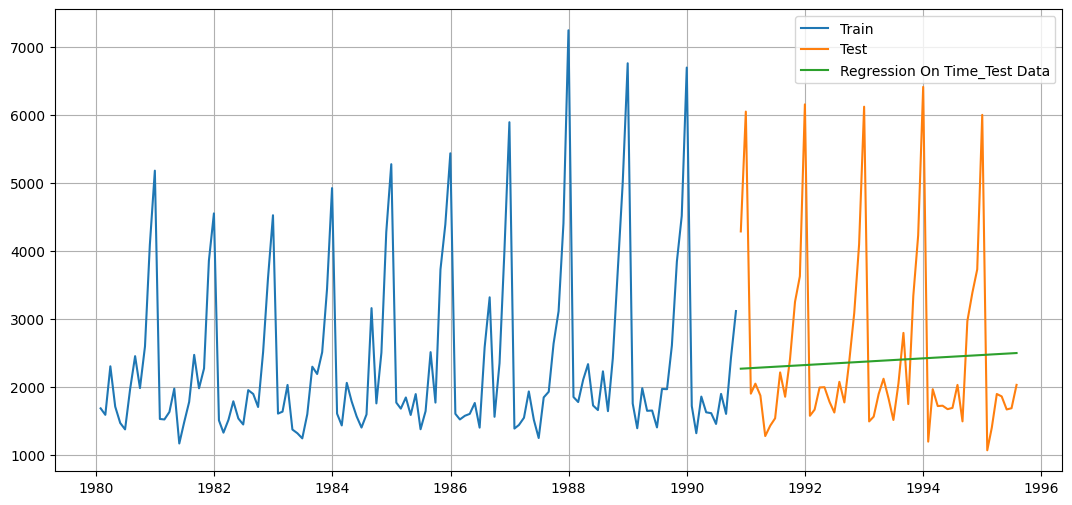

In [34]:
test_predictions_model1         = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model1

plt.figure(figsize=(13,6))
plt.plot( train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')
plt.legend(loc='best')
plt.grid();

### Model Evaluation

In [35]:
from sklearn import metrics
## Test Data - RMSE

rmse_model1_test = metrics.mean_squared_error(test['Sparkling'],test_predictions_model1,squared=False)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.2f" %(rmse_model1_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 1374.55


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [36]:
resultsDf = pd.DataFrame({'Test RMSE': [rmse_model1_test]},index=['RegressionOnTime'])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202


## Method 2: Moving Average(MA)

For the moving average model, we are going to calculate rolling means (or moving averages) for different intervals. The best interval can be determined by the maximum accuracy (or the minimum error) over here.
- For Moving Average, we are going to average over the entire data.

In [37]:
MovingAverage = df1.copy()
MovingAverage.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


###Trailing moving averages

In [38]:

MovingAverage['Trailing_2'] = MovingAverage['Sparkling'].rolling(2).mean()
MovingAverage['Trailing_4'] = MovingAverage['Sparkling'].rolling(4).mean()
MovingAverage['Trailing_6'] = MovingAverage['Sparkling'].rolling(6).mean()
MovingAverage['Trailing_9'] = MovingAverage['Sparkling'].rolling(9).mean()

MovingAverage.head()

,Sparkling,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1980-01-31,1686,NaN,NaN,NaN,NaN
1980-02-29,1591,1638.5,NaN,NaN,NaN
1980-03-31,2304,1947.5,NaN,NaN,NaN
1980-04-30,1712,2008.0,1823.25,NaN,NaN
1980-05-31,1471,1591.5,1769.50,NaN,NaN


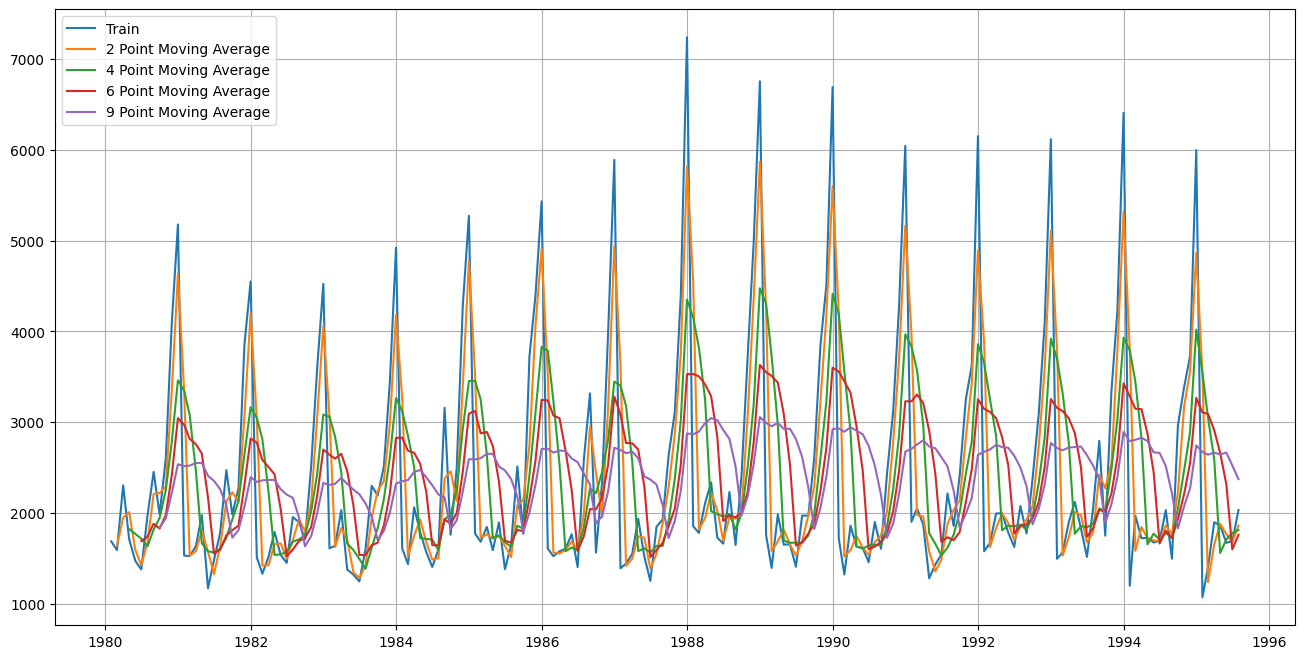

In [39]:
## Plotting on the whole data

plt.figure(figsize=(16,8))
plt.plot(MovingAverage['Sparkling'], label='Train')
plt.plot(MovingAverage['Trailing_2'], label='2 Point Moving Average')
plt.plot(MovingAverage['Trailing_4'], label='4 Point Moving Average')
plt.plot(MovingAverage['Trailing_6'],label = '6 Point Moving Average')
plt.plot(MovingAverage['Trailing_9'],label = '9 Point Moving Average')

plt.legend(loc = 'best')
plt.grid();

Let us split the data into train and test and plot this Time Series. The window of the moving average is need to be carefully selected as too big a window will result in not having any test set as the whole series might get averaged over.

In [40]:
#Creating train and test set
trailing_MovingAverage_train=MovingAverage[0:int(len(MovingAverage)*0.7)]
trailing_MovingAverage_test=MovingAverage[int(len(MovingAverage)*0.7):]

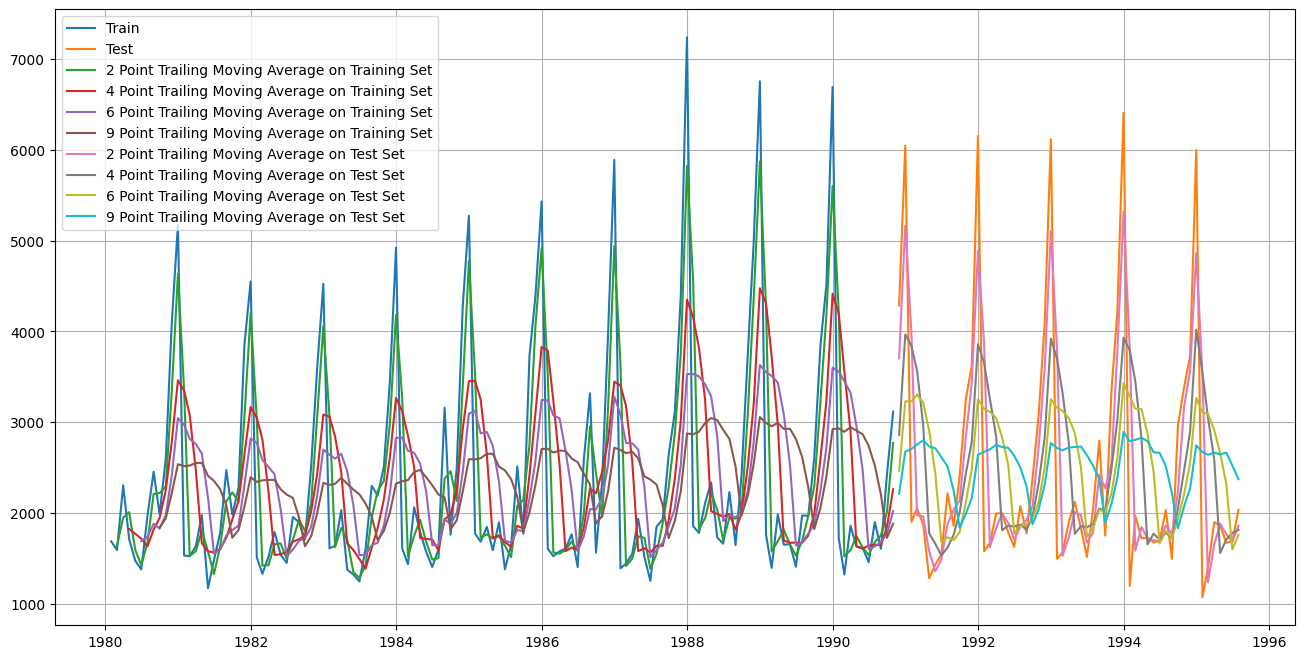

In [41]:
## Plotting on both the Training and Test data

plt.figure(figsize=(16,8))
plt.plot(trailing_MovingAverage_train['Sparkling'], label='Train')
plt.plot(trailing_MovingAverage_test['Sparkling'], label='Test')

plt.plot(trailing_MovingAverage_train['Trailing_2'], label='2 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_4'], label='4 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_6'],label = '6 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_9'],label = '9 Point Trailing Moving Average on Training Set')

plt.plot(trailing_MovingAverage_test['Trailing_2'], label='2 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_4'], label='4 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_6'],label = '6 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_9'],label = '9 Point Trailing Moving Average on Test Set')
plt.legend(loc = 'best')
plt.grid();

###Model Evaluation

In [42]:
import numpy as np

####MAPE SCORE

In [43]:
#Test Data - MAPE --> 2 point Trailing MA
mape_model1_test = np.mean(np.abs((test['Sparkling'] - test_predictions_model1)/test['Sparkling']))*100
print("For RegressionOnTime forecast on the Test Data,  MAPE is %3.2f" %(mape_model1_test))

For RegressionOnTime forecast on the Test Data,  MAPE is 39.20


####RMSE SCORE

In [44]:
## Test Data - RMSE --> 2 point Trailing MA

rmse_model4_test_2 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_2'],squared=False)
print("For 2 point Moving Average Model forecast on the Training Data,  RMSE is %3.3f" %(rmse_model4_test_2))

## Test Data - RMSE  --> 4 point Trailing MA

rmse_model4_test_4 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_4'],squared=False)
print("For 4 point Moving Average Model forecast on the Training Data,  RMSE is %3.3f" %(rmse_model4_test_4))

## Test Data - RMSE --> 6 point Trailing MA

rmse_model4_test_6 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_6'],squared=False)
print("For 6 point Moving Average Model forecast on the Training Data,  RMSE is %3.3f" %(rmse_model4_test_6))

## Test Data - RMSE  --> 9 point Trailing MA

rmse_model4_test_9 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_9'],squared=False)
print("For 9 point Moving Average Model forecast on the Training Data,  RMSE is %3.3f " %(rmse_model4_test_9))

For 2 point Moving Average Model forecast on the Training Data,  RMSE is 811.179
For 4 point Moving Average Model forecast on the Training Data,  RMSE is 1184.213
For 6 point Moving Average Model forecast on the Training Data,  RMSE is 1337.201
For 9 point Moving Average Model forecast on the Training Data,  RMSE is 1422.653 


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

In [45]:
resultsDf_4 = pd.DataFrame({'Test RMSE': [rmse_model4_test_2,rmse_model4_test_4
                                          ,rmse_model4_test_6,rmse_model4_test_9]}
                           ,index=['2pointTrailingMovingAverage','4pointTrailingMovingAverage'
                                   ,'6pointTrailingMovingAverage','9pointTrailingMovingAverage'])

resultsDf = pd.concat([resultsDf, resultsDf_4])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281


Before we go on to build the various Exponential Smoothing models, let us plot all the models and compare the Time Series plots.

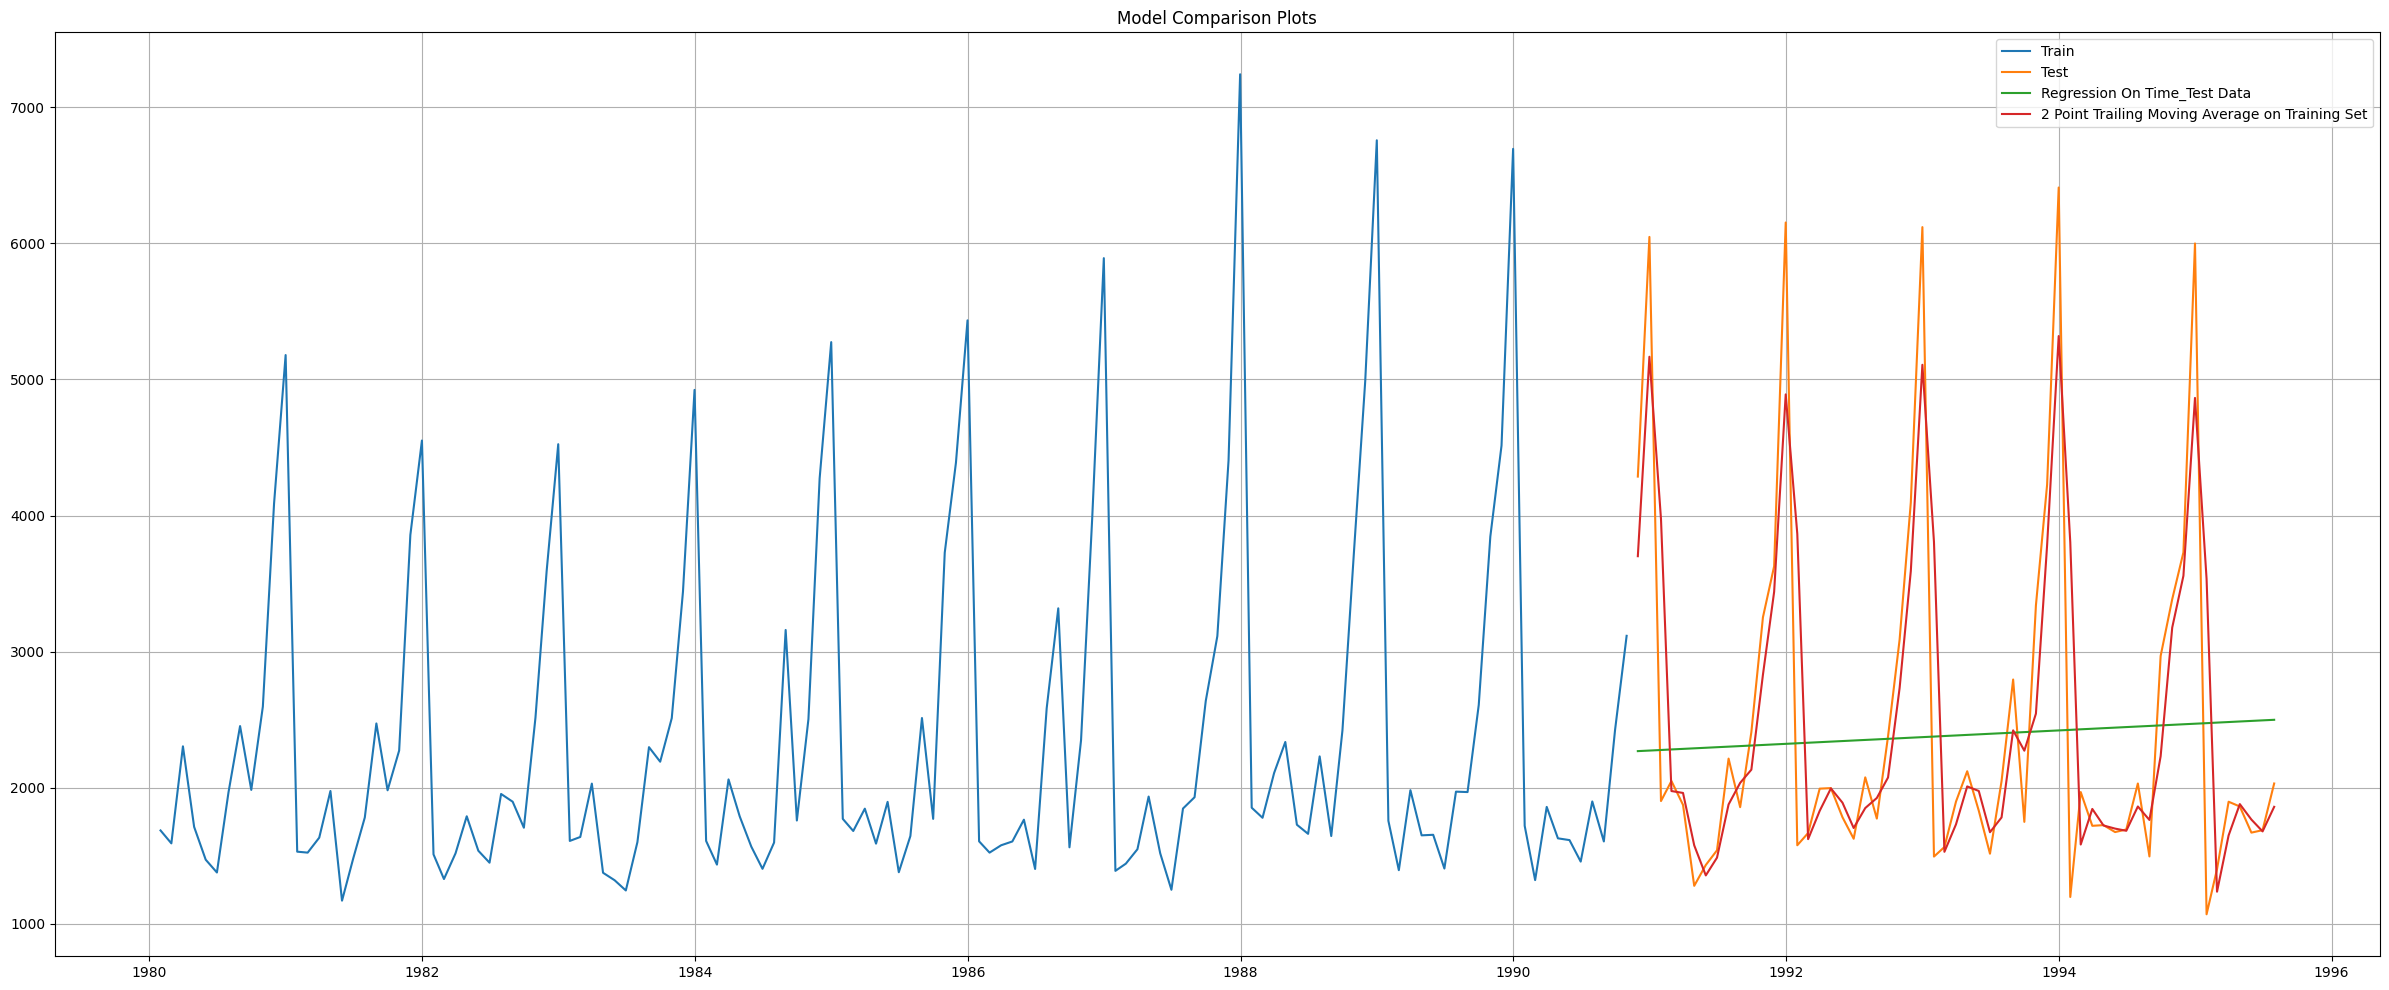

In [46]:
## Plotting on both Training and Test data

plt.figure(figsize=(30,12))
plt.plot(train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')

plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')


plt.plot(trailing_MovingAverage_test['Trailing_2'], label='2 Point Trailing Moving Average on Training Set')


plt.legend(loc='best')
plt.title("Model Comparison Plots")
plt.grid();

## Method 3: Simple Exponential Smoothing

In [47]:
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
SES_train = train.copy()
SES_test = test.copy()

In [48]:
SES_test.isna().sum()

,0
Sparkling,0


In [49]:
model_SES = SimpleExpSmoothing(SES_train['Sparkling'])

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [50]:
model_SES_autofit = model_SES.fit(optimized=True)

In [51]:
model_SES_autofit.params

{'smoothing_level': 0.037534299016257884,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 1686.0,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [52]:
SES_test['predict'] = model_SES_autofit.forecast(steps=len(test))
SES_test.head()

,Sparkling,predict
Time_Stamp,,
1990-11-30,4286,2465.235698
1990-12-31,6047,2465.235698
1991-01-31,1902,2465.235698
1991-02-28,2049,2465.235698
1991-03-31,1874,2465.235698


In [53]:
SES_test.isna().sum()

,0
Sparkling,0
predict,0


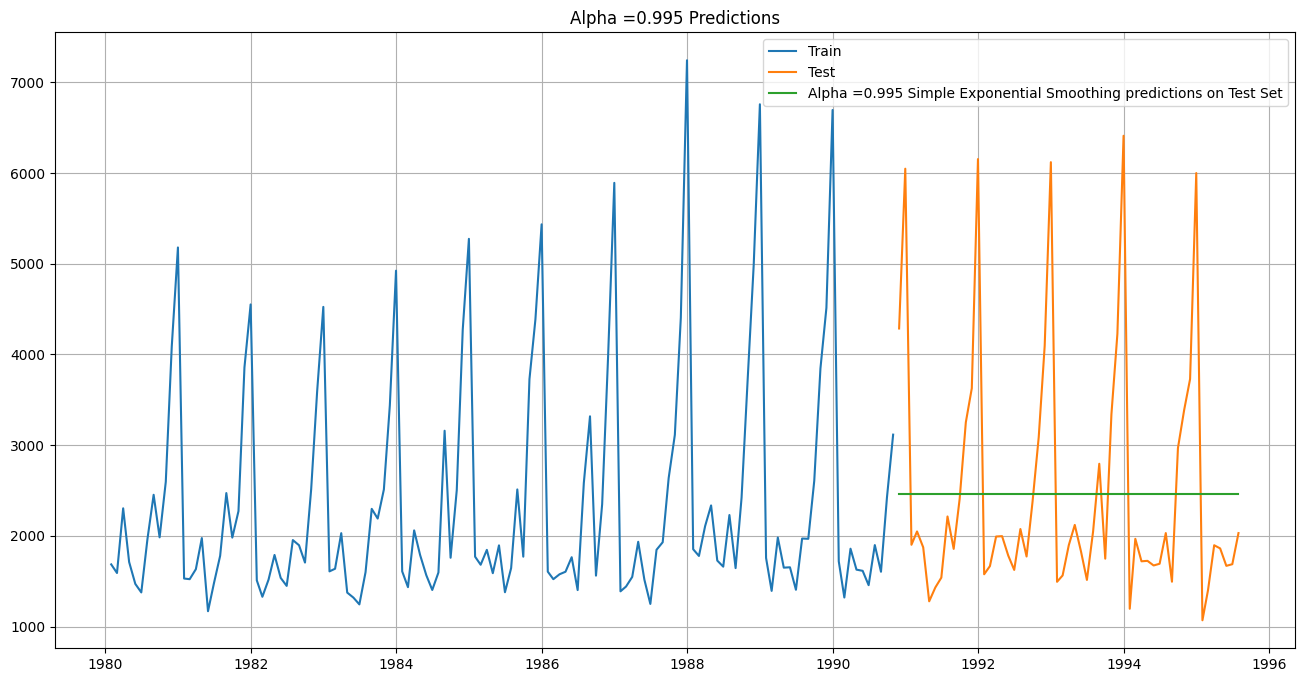

In [54]:
## Plotting on both the Training and Test data

plt.figure(figsize=(16,8))
plt.plot(SES_train['Sparkling'], label='Train')
plt.plot(SES_test['Sparkling'], label='Test')

plt.plot(SES_test['predict'], label='Alpha =0.995 Simple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Alpha =0.995 Predictions');

In [55]:
SES_test.isna().sum()

,0
Sparkling,0
predict,0


### Model Evaluation for $\alpha$ = 0.995 : Simple Exponential Smoothing

In [56]:
## Test Data

rmse_model5_test_1 = metrics.mean_squared_error(SES_test['Sparkling'],SES_test['predict'],squared=False)
print("For Alpha =0.995 Simple Exponential Smoothing Model forecast on the Test Data, RMSE is %3.3f" %(rmse_model5_test_1))

For Alpha =0.995 Simple Exponential Smoothing Model forecast on the Test Data, RMSE is 1362.429


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [57]:
resultsDf_5 = pd.DataFrame({'Test RMSE': [rmse_model5_test_1]},index=['Alpha=0.995,SimpleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_5])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949


In [58]:
SES_test.isna().sum()

,0
Sparkling,0
predict,0


#### Setting different alpha values.

###### Remember, the higher the alpha value more weightage is given to the more recent observation. That means, what happened recently will happen again.


#### We will run a loop with different alpha values to understand which particular value works best for alpha on the test set.

In [59]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_6 = pd.DataFrame({'Alpha Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_6

,Alpha Values,Train RMSE,Test RMSE


In [60]:
SES_test.isna().sum()

,0
Sparkling,0
predict,0


In [61]:
for i in np.arange(0.3,1,0.1):
    model_SES_alpha_i = model_SES.fit(smoothing_level=i,optimized=False,use_brute=True)
    SES_train['predict',i] = model_SES_alpha_i.fittedvalues
    SES_test['predict',i] = model_SES_alpha_i.forecast(steps=57) # steps 57 from the splitting the data and check the test number of rows

    rmse_model5_train_i = metrics.mean_squared_error(SES_train['Sparkling'],SES_train['predict',i],squared=False)

    rmse_model5_test_i = metrics.mean_squared_error(SES_test['Sparkling'],SES_test['predict',i],squared=False)

    # Create a new row as a DataFrame
    new_row = pd.DataFrame({'Alpha Values': [i],
                            'Train RMSE': [rmse_model5_train_i],
                            'Test RMSE': [rmse_model5_test_i]})

    # Append the new row using pd.concat
    resultsDf_6 = pd.concat([resultsDf_6, new_row], ignore_index=True)

  ##resultsDf_6 = pd.concat({'Alpha Values':i,'Train RMSE':rmse_model5_train_i
                                    ##  ,'Test RMSE':rmse_model5_test_i}, ignore_index=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

In [62]:
SES_test.isna().sum()

,0
Sparkling,0
predict,0
"(predict, 0.3)",0
"(predict, 0.4)",0
"(predict, 0.5)",0
"(predict, 0.6000000000000001)",0
"(predict, 0.7000000000000002)",0
"(predict, 0.8000000000000003)",0
"(predict, 0.9000000000000001)",0


In [63]:
'''for i in np.arange(0.3, 1, 0.1):
    model_SES_alpha_i = model_SES.fit(smoothing_level=i, optimized=False, use_brute=True)

    # Store predictions
    SES_train[f'predict_{i}'] = model_SES_alpha_i.fittedvalues
    SES_test[f'predict_{i}'] = model_SES_alpha_i.forecast(steps=18)

    # Calculate RMSE
    rmse_model5_train_i = metrics.mean_squared_error(
        SES_train['Sparkling'],
        SES_train[f'predict_{i}'],
        squared=False
    )

    rmse_model5_test_i = metrics.mean_squared_error(
        SES_test['Sparkling'],
        SES_test[f'predict_{i}'],
        squared=False
    )

    # Create a new row as a DataFrame
    new_row = pd.DataFrame({'Alpha Values': [i],
                            'Train RMSE': [rmse_model5_train_i],
                            'Test RMSE': [rmse_model5_test_i]})

    # Append the new row using pd.concat
    resultsDf_6 = pd.concat([resultsDf_6, new_row], ignore_index=True)'''

"for i in np.arange(0.3, 1, 0.1):\n    model_SES_alpha_i = model_SES.fit(smoothing_level=i, optimized=False, use_brute=True)\n\n    # Store predictions\n    SES_train[f'predict_{i}'] = model_SES_alpha_i.fittedvalues\n    SES_test[f'predict_{i}'] = model_SES_alpha_i.forecast(steps=18)\n\n    # Calculate RMSE\n    rmse_model5_train_i = metrics.mean_squared_error(\n        SES_train['Sparkling'],\n        SES_train[f'predict_{i}'],\n        squared=False\n    )\n\n    rmse_model5_test_i = metrics.mean_squared_error(\n        SES_test['Sparkling'],\n        SES_test[f'predict_{i}'],\n        squared=False\n    )\n\n    # Create a new row as a DataFrame\n    new_row = pd.DataFrame({'Alpha Values': [i],\n                            'Train RMSE': [rmse_model5_train_i],\n                            'Test RMSE': [rmse_model5_test_i]})\n\n    # Append the new row using pd.concat\n    resultsDf_6 = pd.concat([resultsDf_6, new_row], ignore_index=True)"

In [64]:
resultsDf_6.sort_values(by=['Test RMSE'],ascending=True)

,Alpha Values,Train RMSE,Test RMSE
1,0.4,1329.814823,1363.037803
2,0.5,1326.403864,1364.863549
0,0.3,1331.102204,1372.323705
3,0.6,1325.588422,1379.988733
4,0.7,1329.257530,1404.659104
5,0.8,1337.879425,1434.578214
6,0.9,1351.645478,1466.179706


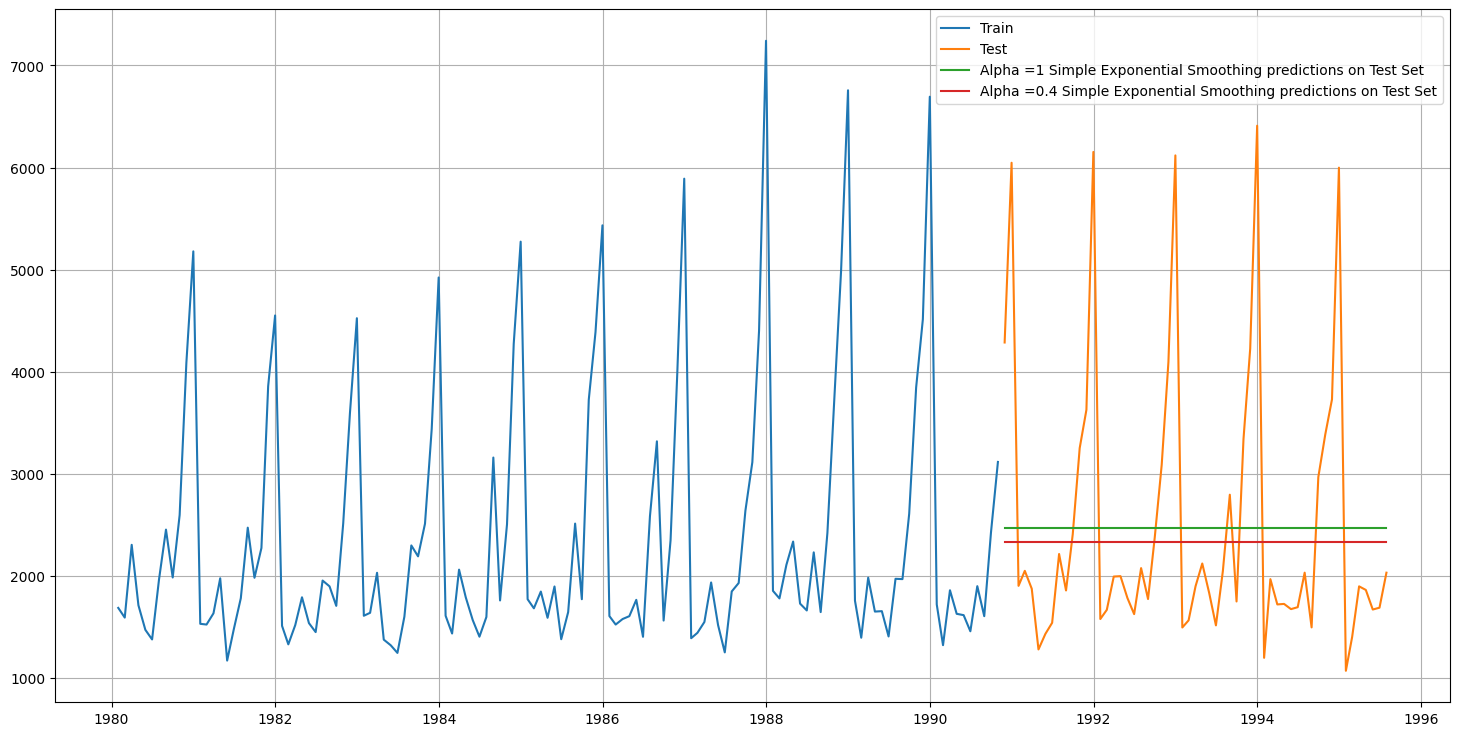

In [65]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(SES_train['Sparkling'], label='Train')
plt.plot(SES_test['Sparkling'], label='Test')

plt.plot(SES_test['predict'], label='Alpha =1 Simple Exponential Smoothing predictions on Test Set')

plt.plot(SES_test['predict', 0.3], label='Alpha =0.4 Simple Exponential Smoothing predictions on Test Set')



plt.legend(loc='best')
plt.grid();

In [66]:
resultsDf_6_1 = pd.DataFrame({'Test RMSE': [resultsDf_6.sort_values(by=['Test RMSE'],ascending=True).values[0][2]]}
                           ,index=['Alpha=0.4,SimpleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_6_1])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803


## Method 4: Double Exponential Smoothing (Holt's Model)

##### Two parameters $\alpha$ and $\beta$ are estimated in this model. Level and Trend are accounted for in this model.

In [67]:
DES_train = train.copy()
DES_test = test.copy()

In [68]:
model_DES = Holt(DES_train['Sparkling'])

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [69]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_7 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_7

,Alpha Values,Beta Values,Train RMSE,Test RMSE


In [70]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        model_DES_alpha_i_j = model_DES.fit(smoothing_level=i,smoothing_trend=j,optimized=False,use_brute=True)
        DES_train['predict',i,j] = model_DES_alpha_i_j.fittedvalues
        DES_test['predict',i,j] = model_DES_alpha_i_j.forecast(steps=57)

        rmse_model6_train = metrics.mean_squared_error(DES_train['Sparkling'],DES_train['predict',i,j],squared=False)

        rmse_model6_test = metrics.mean_squared_error(DES_test['Sparkling'],DES_test['predict',i,j],squared=False)

        # Create a new row as a DataFrame
        new_row = pd.DataFrame({
            'Alpha Values': [i],
            'Beta Values': [j],
            'Train RMSE': [rmse_model6_train],
            'Test RMSE': [rmse_model6_test]
        })

        # Append the new row using pd.concat
        resultsDf_7 = pd.concat([resultsDf_7, new_row], ignore_index=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

In [71]:
resultsDf_7

,Alpha Values,Beta Values,Train RMSE,Test RMSE
0,0.3,0.3,1567.524066,1597.853999
1,0.3,0.4,1662.549225,4023.672164
2,0.3,0.5,1758.543876,8879.172380
3,0.3,0.6,1843.560670,15645.080035
4,0.3,0.7,1902.735965,23205.442323
...,...,...,...,...
59,1.0,0.6,1764.658812,20558.025827
60,1.0,0.7,1837.425218,22155.074151
61,1.0,0.8,1915.148280,23241.839479
62,1.0,0.9,1999.362743,23787.747852


Let us sort the data frame in the ascending ordering of the 'Test RMSE' and the 'Test MAPE' values.

In [72]:
resultsDf_7.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Train RMSE,Test RMSE
0,0.3,0.3,1567.524066,1597.853999
1,0.3,0.4,1662.549225,4023.672164
8,0.4,0.3,1556.795694,5049.478887
16,0.5,0.3,1525.615506,7817.569799
2,0.3,0.5,1758.543876,8879.172380


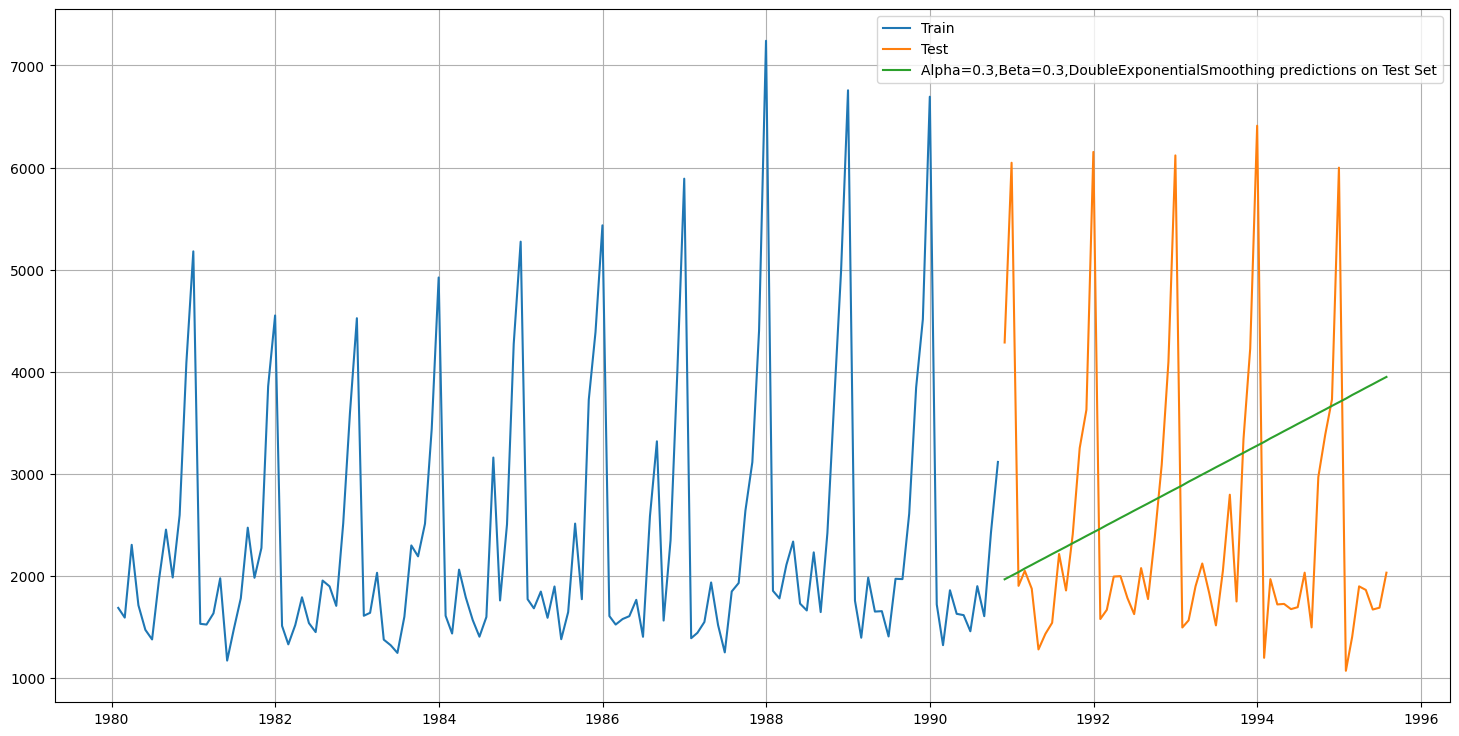

In [73]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(DES_train['Sparkling'], label='Train')
plt.plot(DES_test['Sparkling'], label='Test')

plt.plot(DES_test['predict', 0.3, 0.3], label='Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing predictions on Test Set')


plt.legend(loc='best')
plt.grid();

In [74]:
resultsDf_7_1 = pd.DataFrame({'Test RMSE': [resultsDf_7.sort_values(by=['Test RMSE']).values[0][3]]}
                           ,index=['Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_7_1])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999


## Method 5: Triple Exponential Smoothing (Holt - Winter's Model)

##### Three parameters $\alpha$, $\beta$ and $\gamma$ are estimated in this model. Level, Trend and Seasonality are accounted for in this model.

In [75]:
TES_train = train.copy()
TES_test = test.copy()

In [76]:
model_TES = ExponentialSmoothing(TES_train['Sparkling'],trend='additive',seasonal='multiplicative',freq='M')

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:595: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = to_offset(freq)


In [77]:
model_TES_autofit = model_TES.fit()

The above fit of the model is by the best parameters that Python thinks for the model. It uses a brute force method to choose the parameters.

In [78]:
model_TES_autofit.params

{'smoothing_level': 0.07571445210103464,
 'smoothing_trend': 0.06489808813237438,
 'smoothing_seasonal': 0.3765608370780376,
 'damping_trend': nan,
 'initial_level': 2356.54174944041,
 'initial_trend': -9.180926180482402,
 'initial_seasons': array([0.71186629, 0.67768289, 0.89647955, 0.79722705, 0.64099767,
        0.64026213, 0.86701095, 1.11336214, 0.89797444, 1.18549449,
        1.8343214 , 2.32723166]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [79]:
## Prediction on the test data

TES_test['auto_predict'] = model_TES_autofit.forecast(steps=len(test))
TES_test.head()
TES_test_0=TES_test

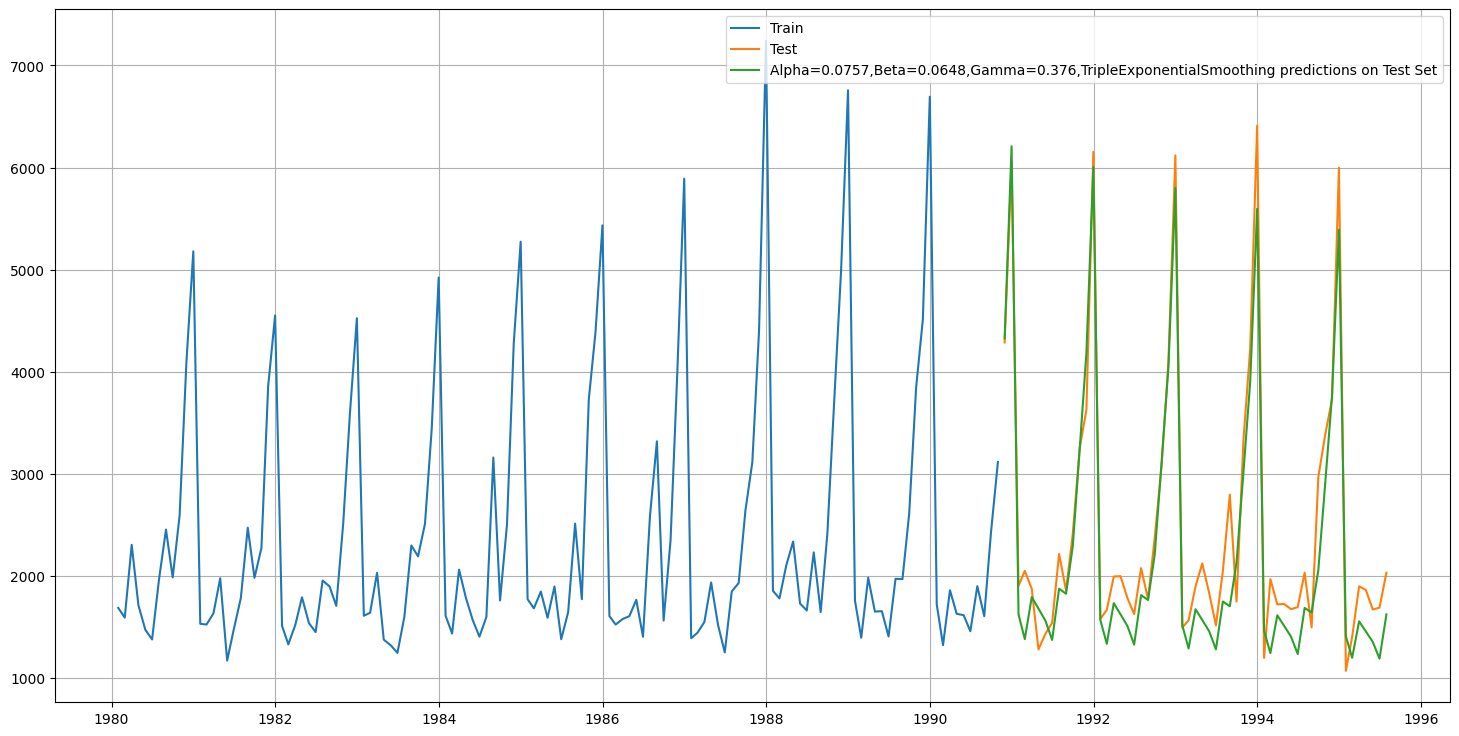

In [80]:
## Plotting on both the Training and Test using autofit

plt.figure(figsize=(18,9))
plt.plot(TES_train['Sparkling'], label='Train')
plt.plot(TES_test['Sparkling'], label='Test')

plt.plot(TES_test['auto_predict'], label='Alpha=0.0757,Beta=0.0648,Gamma=0.376,TripleExponentialSmoothing predictions on Test Set')


plt.legend(loc='best')
plt.grid();

In [81]:
## Test Data

rmse_model6_test_1 = metrics.mean_squared_error(TES_test_0['Sparkling'],TES_test_0['auto_predict'],squared=False)
print("For Alpha=0.0757,Beta=0.0648,Gamma=0.376, Triple Exponential Smoothing Model forecast on the Test Data,  RMSE is %3.3f" %(rmse_model6_test_1))

For Alpha=0.0757,Beta=0.0648,Gamma=0.376, Triple Exponential Smoothing Model forecast on the Test Data,  RMSE is 381.657


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [82]:
resultsDf_8_1 = pd.DataFrame({'Test RMSE': [rmse_model6_test_1]}
                           ,index=['Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_8_1])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232


In [83]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_8_2 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Gamma Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_8_2

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE


In [84]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        for k in np.arange(0.3,1.1,0.1):
            model_TES_alpha_i_j_k = model_TES.fit(smoothing_level=i,smoothing_trend=j,smoothing_seasonal=k,optimized=False,use_brute=True)
            TES_train['predict',i,j,k] = model_TES_alpha_i_j_k.fittedvalues
            TES_test['predict',i,j,k] = model_TES_alpha_i_j_k.forecast(steps=57)

            rmse_model8_train = metrics.mean_squared_error(TES_train['Sparkling'],TES_train['predict',i,j,k],squared=False)

            rmse_model8_test = metrics.mean_squared_error(TES_test['Sparkling'],TES_test['predict',i,j,k],squared=False)


 # Create a new row as a DataFrame
        new_row = pd.DataFrame({
            'Alpha Values': [i],
            'Beta Values': [j],
            'Gamma Values':[k],
            'Train RMSE': [rmse_model8_train],
            'Test RMSE': [rmse_model8_test]
        })

        # Append the new row using pd.concat
        resultsDf_8_2 = pd.concat([resultsDf_8_2, new_row], ignore_index=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

In [85]:
resultsDf_8_2

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE
0,0.3,0.3,1.0,662.225786,5232.955827
1,0.3,0.4,1.0,764.364092,18682.784367
2,0.3,0.5,1.0,783.736036,1656.729104
3,0.3,0.6,1.0,1324.157442,210938.222669
4,0.3,0.7,1.0,6736.776499,59940.824678
...,...,...,...,...,...
59,1.0,0.6,1.0,36110.512399,219753.436457
60,1.0,0.7,1.0,14642.980877,64711.137504
61,1.0,0.8,1.0,17843.597581,101629.977419
62,1.0,0.9,1.0,140179.614556,102109.624795


In [86]:
resultsDf_8_2.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE
2,0.3,0.5,1.0,783.736036,1656.729104
0,0.3,0.3,1.0,662.225786,5232.955827
32,0.7,0.3,1.0,1794.758979,6578.291633
8,0.4,0.3,1.0,818.205078,7200.667010
56,1.0,0.3,1.0,38106.345694,9282.158153


In [87]:

'''## Plotting on both the Training and Test data using brute force alpha, beta and gamma determination

plt.figure(figsize=(18,9))
plt.plot(TES_train['Sparkling'], label='Train')
plt.plot(TES_test['Sparkling'], label='Test')
TES_test.reset_index(drop=True)
#The value of alpha and beta is taken like that by python
plt.plot(TES_test['predict', 0.302, 0.502, 1.001], label='Alpha=1.0,Beta=0.7,Gamma=0.3,TripleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid();

'''

"## Plotting on both the Training and Test data using brute force alpha, beta and gamma determination\n\nplt.figure(figsize=(18,9))\nplt.plot(TES_train['Sparkling'], label='Train')\nplt.plot(TES_test['Sparkling'], label='Test')\nTES_test.reset_index(drop=True)\n#The value of alpha and beta is taken like that by python\nplt.plot(TES_test['predict', 0.302, 0.502, 1.001], label='Alpha=1.0,Beta=0.7,Gamma=0.3,TripleExponentialSmoothing predictions on Test Set')\n\nplt.legend(loc='best')\nplt.grid();\n\n"

In [88]:
resultsDf_8_3 = pd.DataFrame({'Test RMSE': [resultsDf_8_2.sort_values(by=['Test RMSE']).values[0][4]]}
                           ,index=['Alpha=0.3,Beta=0.5,Gamma=1.0,TripleExponentialSmoothing'])

resultsDf1 = pd.concat([resultsDf, resultsDf_8_3])
resultsDf1

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232
"Alpha=0.3,Beta=0.5,Gamma=1.0,TripleExponentialSmoothing",1656.729104


In [89]:
print('Sorted by RMSE values on the Test Data:','\n',)
resultsDf1.sort_values(by=['Test RMSE'])

Sorted by RMSE values on the Test Data: 



,Test RMSE
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
RegressionOnTime,1374.550202
9pointTrailingMovingAverage,1422.653281
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999
"Alpha=0.3,Beta=0.5,Gamma=1.0,TripleExponentialSmoothing",1656.729104


For this data, we had both trend and seasonality so by definition Triple Exponential Smoothing is supposed to work better than the Simple Exponential Smoothing as well as the Double Exponential Smoothing. However, since this was a model building exercise we had gone on to build different models on the data and have compared these model with the best RMSE value on the test data.

### We see that the best model is the Triple Exponential Smoothing with multiplicative seasonality with the parameters $\alpha$ = 0.3, $\beta$ = 0.5 and $\gamma$ = 1.0.

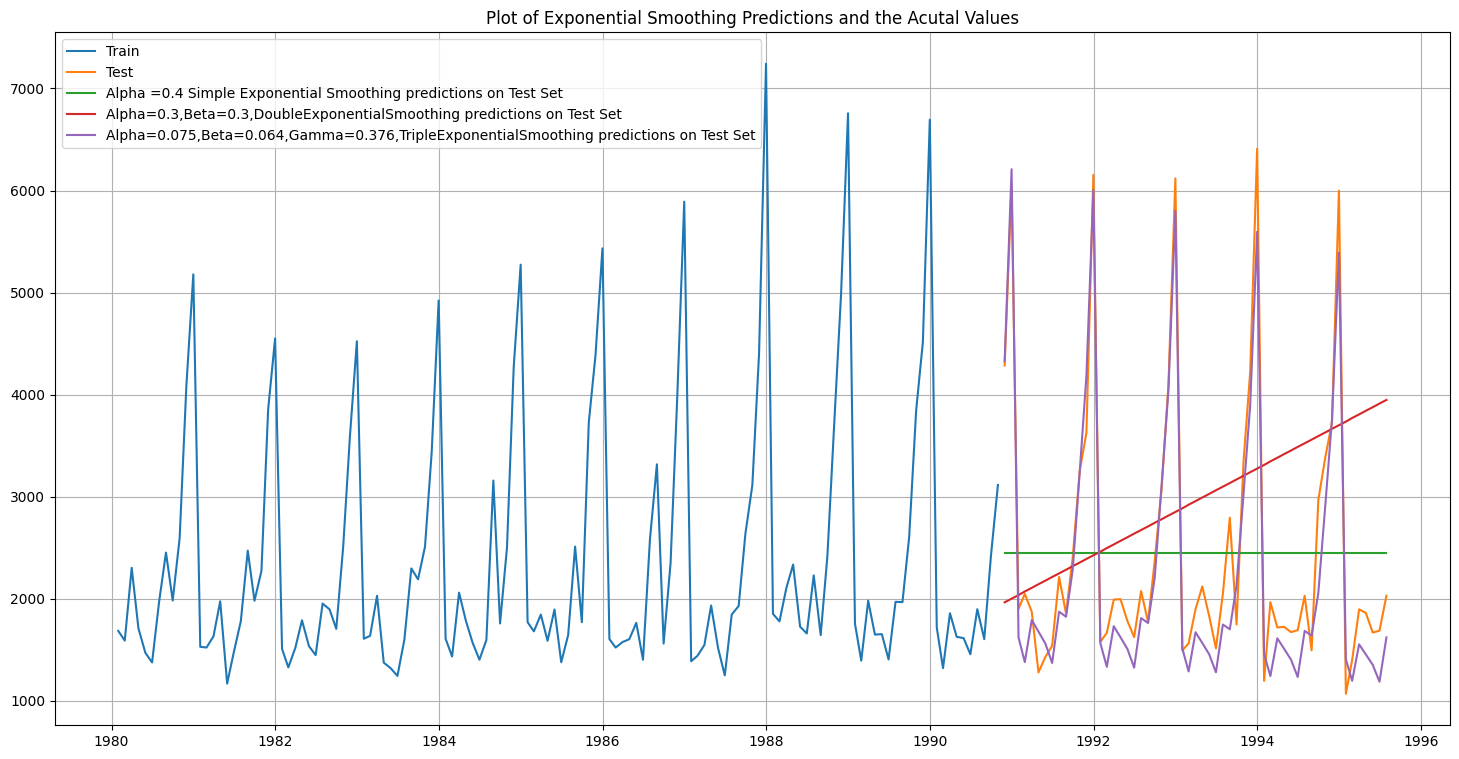

In [90]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')

plt.plot(SES_test['predict', 0.4], label='Alpha =0.4 Simple Exponential Smoothing predictions on Test Set')

plt.plot(DES_test['predict', 0.3, 0.3], label='Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing predictions on Test Set')

plt.plot(TES_test_0['auto_predict'], label='Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid();
plt.title('Plot of Exponential Smoothing Predictions and the Acutal Values');

In this particular we have built several models and went through a model building exercise. This particular exercise has given us an idea as to which particular model gives us the least error on our test set for this data. But in Time Series Forecasting, we need to be very vigil about the fact that after we have done this exercise we need to build the model on the whole data. Remember, the training data that we have used to build the model stops much before the data ends. In order to forecast using any of the models built, we need to build the models again (this time on the complete data) with the same parameters.

For this particular mentored learning session, we will go ahead and build only the top 2 models which gave us the best accuracy (least RMSE).

The best model to be built on the whole data is:

* Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing

In [91]:
fullmodel1 = ExponentialSmoothing(df1,
                                  trend='additive',
                                  seasonal='multiplicative').fit(smoothing_level=0.075,
                                                                 smoothing_trend=0.064,
                                                                 smoothing_seasonal=0.376)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [92]:
RMSE_fullmodel1 = metrics.mean_squared_error(df1['Sparkling'],fullmodel1.fittedvalues,squared=False)

print('RMSE:',RMSE_fullmodel1)

RMSE: 349.2012812408877


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [93]:
# Getting the predictions for the same number of times stamps that are present in the test data
prediction_1 = fullmodel1.forecast(steps=len(test))

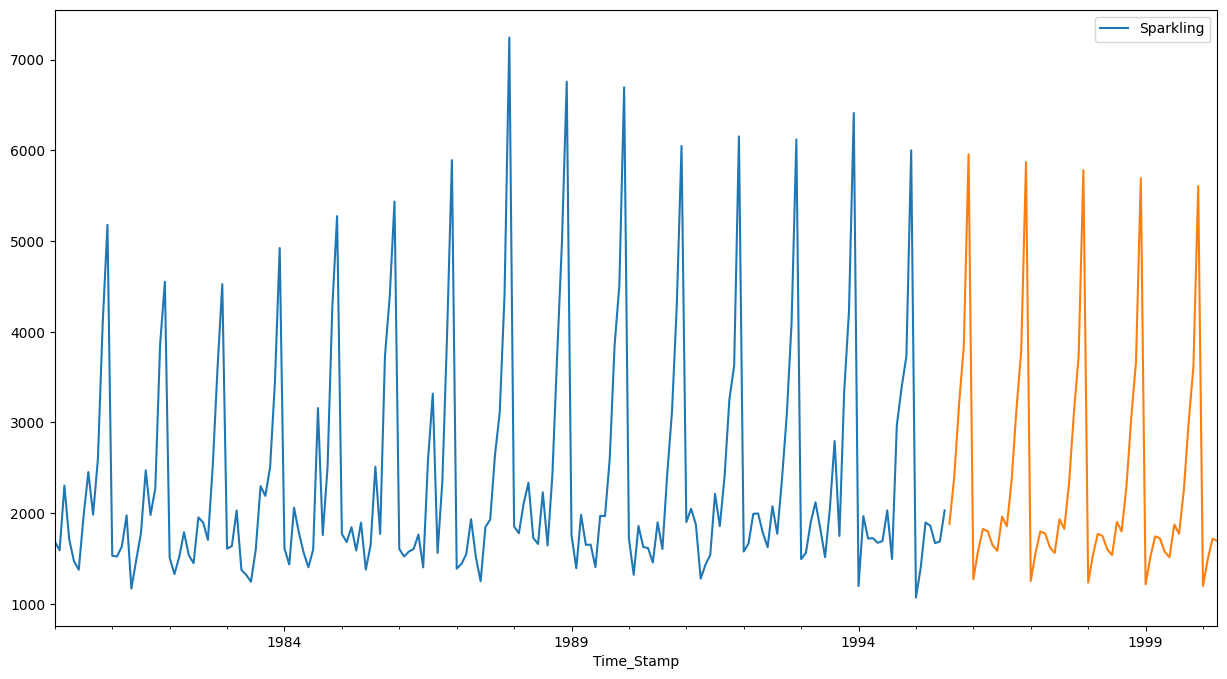

In [94]:
df1.plot()
prediction_1.plot();

One assumption that we have made over here while calculating the confidence bands is that the standard deviation of the forecast distribution is almost equal to the residual standard deviation.

In [95]:
#In the below code, we have calculated the upper and lower confidence bands at 95% confidence level
#Here we are taking the multiplier to be 1.96 as we want to plot with respect to a 95% confidence intervals.
pred_1_df = pd.DataFrame({'lower_CI':prediction_1 - 1.96*np.std(fullmodel1.resid,ddof=1),
                          'prediction':prediction_1,
                          'upper_ci': prediction_1 + 1.96*np.std(fullmodel1.resid,ddof=1)})
pred_1_df.head()

,lower_CI,prediction,upper_ci
1995-08-31,1195.917978,1882.092855,2568.267731
1995-09-30,1714.136751,2400.311627,3086.486504
1995-10-31,2502.872963,3189.047840,3875.222716
1995-11-30,3156.007887,3842.182763,4528.357639
1995-12-31,5270.414923,5956.589800,6642.764676


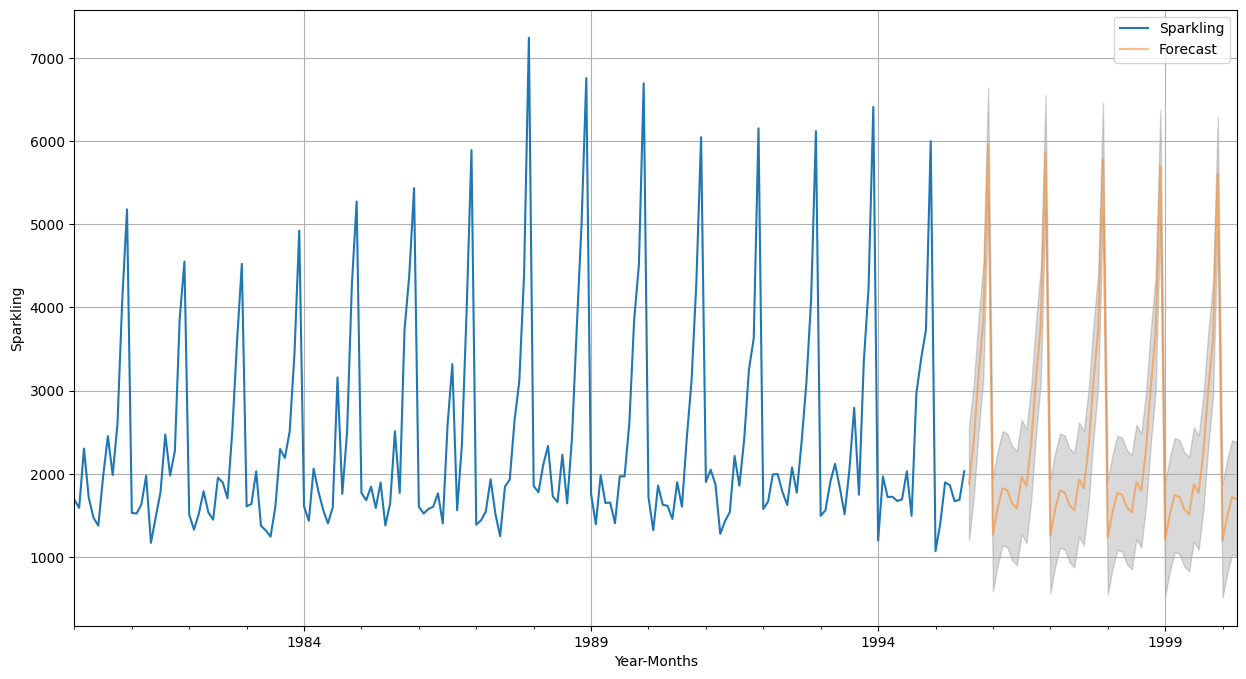

In [96]:
# plot the forecast along with the confidence band

axis = df1.plot(label='Actual', figsize=(15,8))
pred_1_df['prediction'].plot(ax=axis, label='Forecast', alpha=0.5)
axis.fill_between(pred_1_df.index, pred_1_df['lower_CI'], pred_1_df['upper_ci'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.grid()
plt.show()

#Check for stationarity of the whole Time Series data at α =0.05

In [97]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=7).mean() #determining the rolling mean
    rolstd = timeseries.rolling(window=7).std()   #determining the rolling standard deviation

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

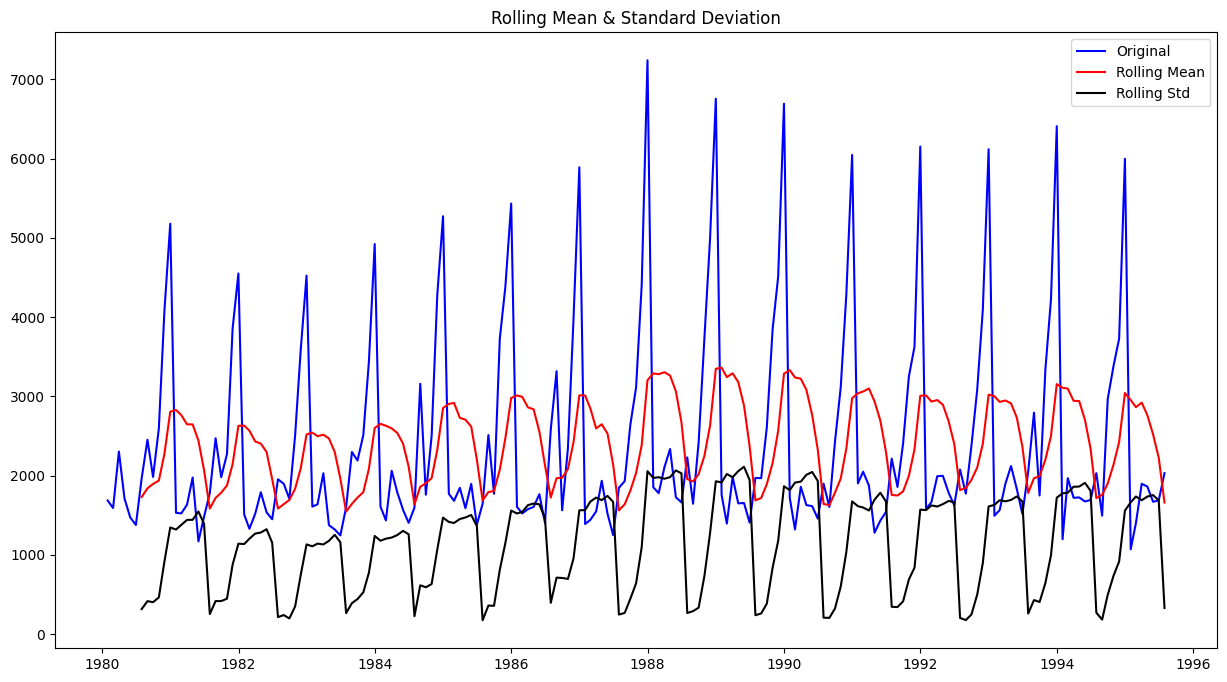

Results of Dickey-Fuller Test:
Test Statistic                  -1.360497
p-value                          0.601061
#Lags Used                      11.000000
Number of Observations Used    175.000000
Critical Value (1%)             -3.468280
Critical Value (5%)             -2.878202
Critical Value (10%)            -2.575653
dtype: float64 



In [98]:
test_stationarity(df1['Sparkling'])

We see that at 5% significant level the Time Series is non-stationary.

Let us take a difference of order 1 and check whether the Time Series is stationary or not.

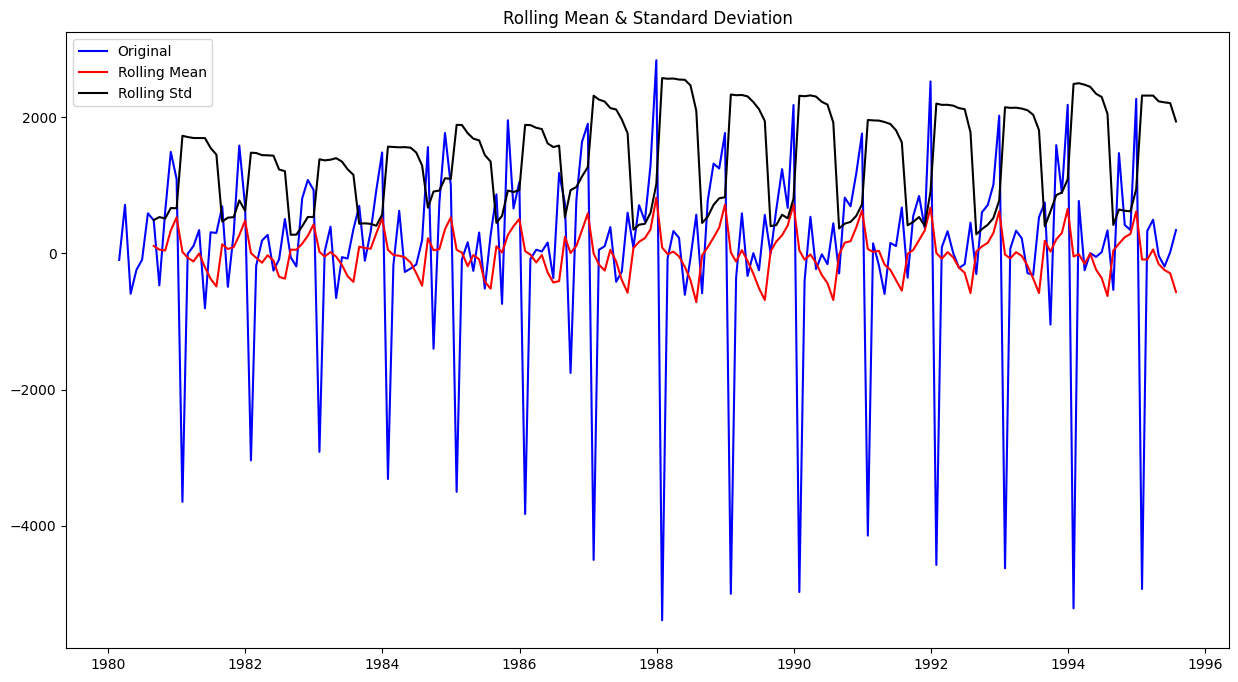

Results of Dickey-Fuller Test:
Test Statistic                 -45.050301
p-value                          0.000000
#Lags Used                      10.000000
Number of Observations Used    175.000000
Critical Value (1%)             -3.468280
Critical Value (5%)             -2.878202
Critical Value (10%)            -2.575653
dtype: float64 



In [99]:
test_stationarity(df1['Sparkling'].diff().dropna())

We see that at $\alpha$ = 0.05 the Time Series is indeed stationary.

# Plot the Autocorrelation function plots on the whole data.

In [100]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

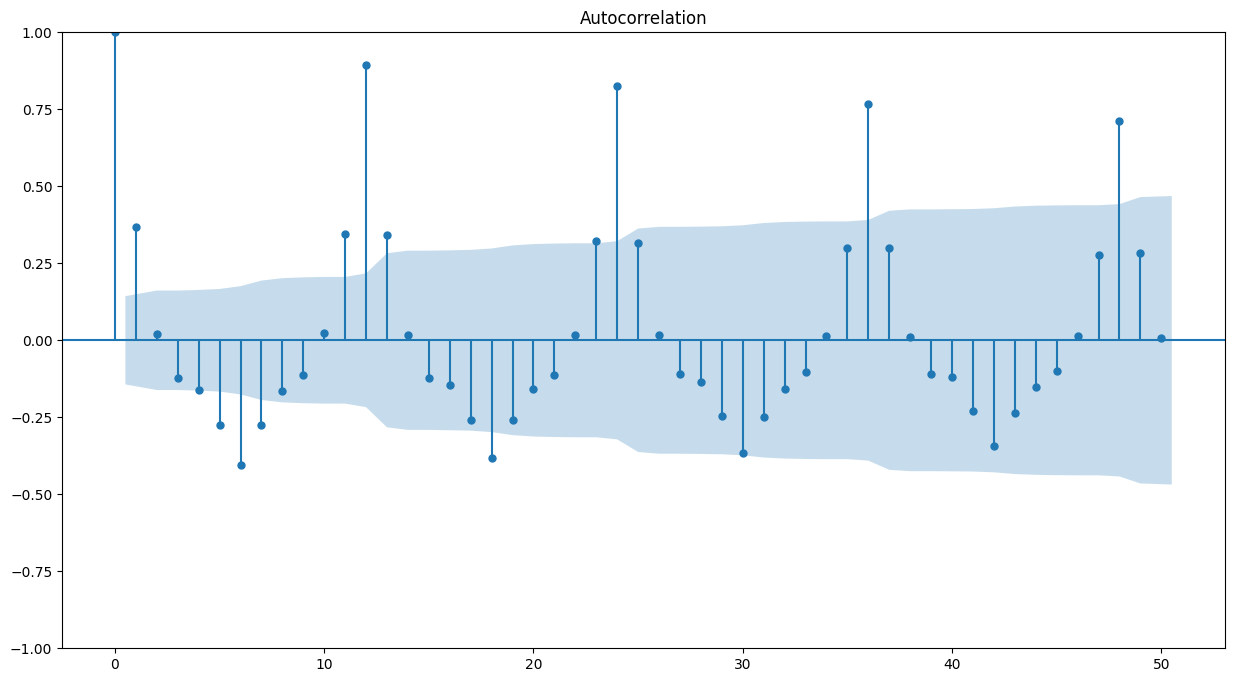

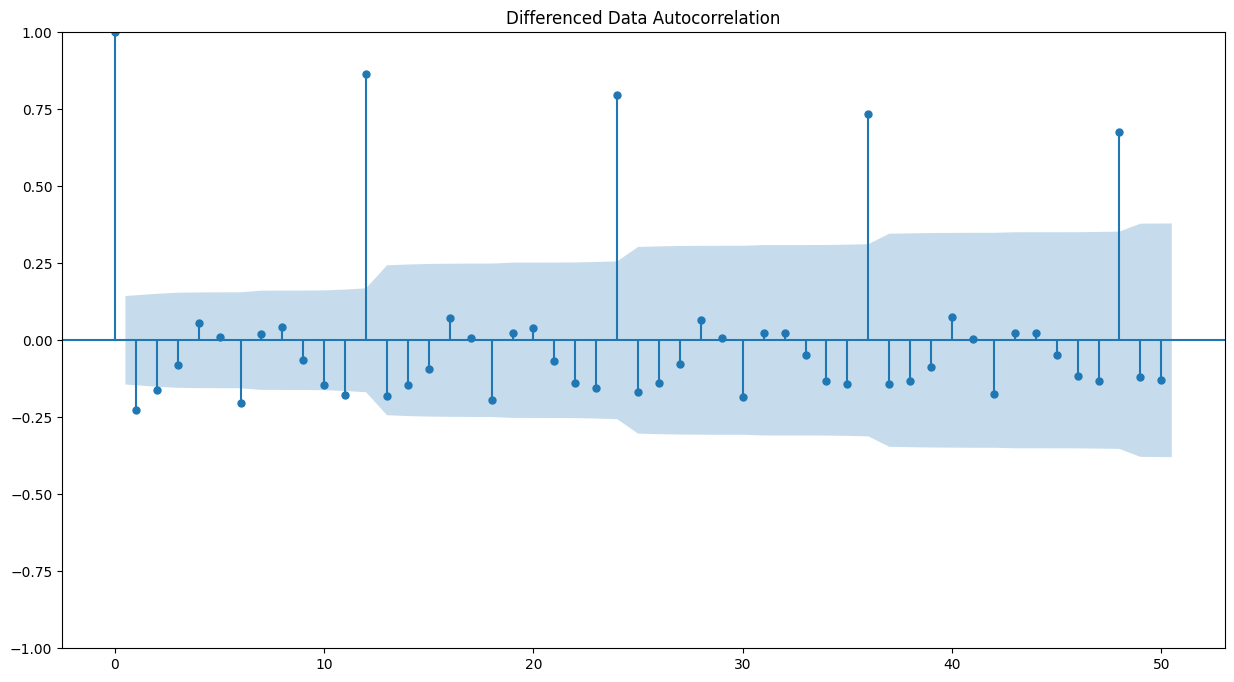

In [101]:
plot_acf(df1['Sparkling'],lags=50)
plot_acf(df1['Sparkling'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plt.show()

From the above plots, we can say that there seems to be a seasonality in the data.

#Split the data into train and test and plot the training and test data.
- Training Data is till the end of 1990. Test Data is from the beginning of 1991 to the last time stamp provided.

In [102]:
train    =   df1[0:int(len(df1)*0.7)]
test     =   df1[int(len(df1)*0.7):]

In [103]:
## This is to display multiple data frames from one cell
from IPython.display import display

In [104]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

First few rows of Training Data


,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


Last few rows of Training Data


,Sparkling
Time_Stamp,
1990-06-30,1457
1990-07-31,1899
1990-08-31,1605
1990-09-30,2424
1990-10-31,3116


First few rows of Test Data


,Sparkling
Time_Stamp,
1990-11-30,4286
1990-12-31,6047
1991-01-31,1902
1991-02-28,2049
1991-03-31,1874


Last few rows of Test Data


,Sparkling
Time_Stamp,
1995-03-31,1897
1995-04-30,1862
1995-05-31,1670
1995-06-30,1688
1995-07-31,2031


In [105]:
print(train.shape)
print(test.shape)

(130, 1)
(57, 1)


#Check for stationarity of the Training Data Time Series.

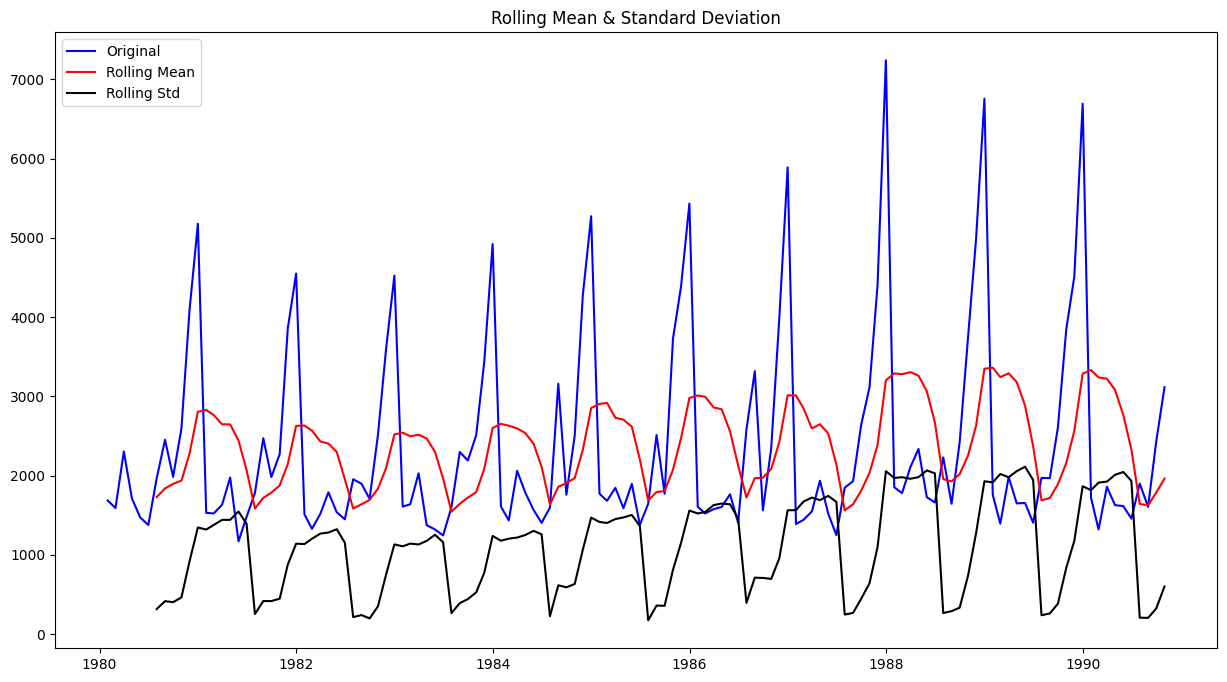

Results of Dickey-Fuller Test:
Test Statistic                  -1.155971
p-value                          0.692243
#Lags Used                      12.000000
Number of Observations Used    117.000000
Critical Value (1%)             -3.487517
Critical Value (5%)             -2.886578
Critical Value (10%)            -2.580124
dtype: float64 



In [106]:
test_stationarity(train['Sparkling'])

We see that the series is not stationary at  α  = 0.05.

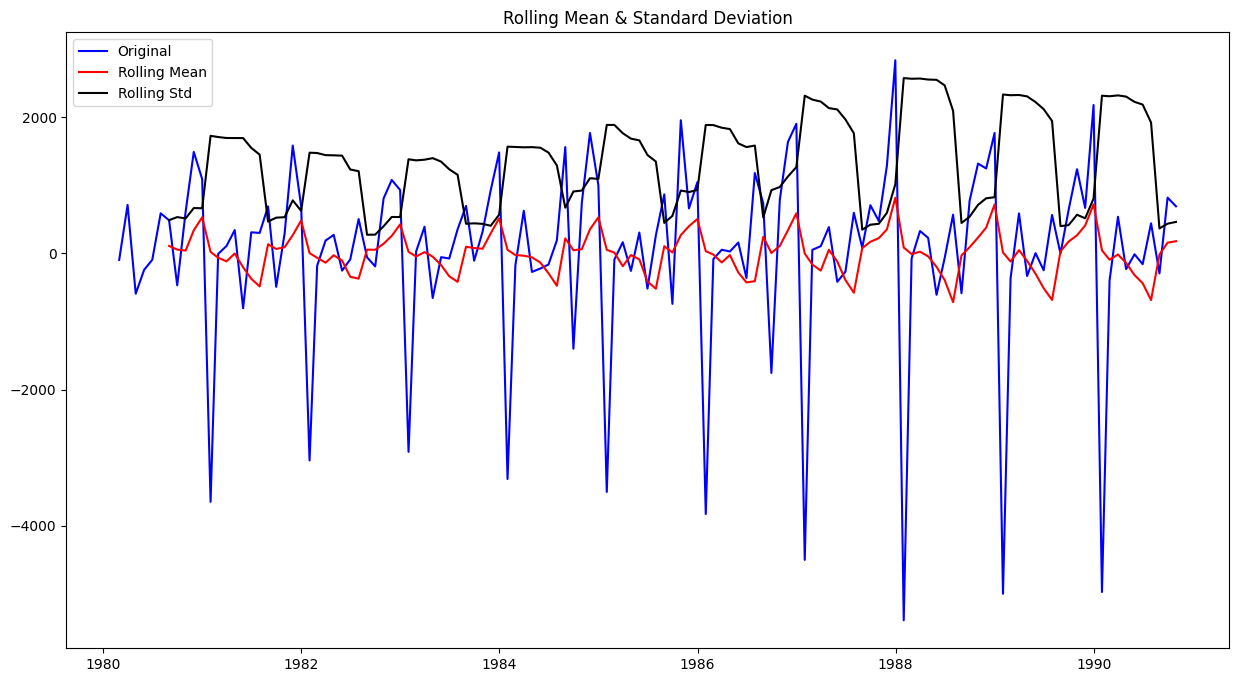

Results of Dickey-Fuller Test:
Test Statistic                -7.876510e+00
p-value                        4.827963e-12
#Lags Used                     1.100000e+01
Number of Observations Used    1.170000e+02
Critical Value (1%)           -3.487517e+00
Critical Value (5%)           -2.886578e+00
Critical Value (10%)          -2.580124e+00
dtype: float64 



In [107]:
test_stationarity(train['Sparkling'].diff().dropna())

We see that after taking a difference of order 1 the series have become stationary at $\alpha$ = 0.05.

Note: If the series is non-stationary, stationarize the Time Series by taking a difference of the Time Series. Then we can use this particular differenced series to train the ARIMA models. We do not need to worry about stationarity for the Test Data because we are not building any models on the Test Data, we are evaluating our models over there. You can look at other kinds of transformations as part of making the time series stationary like taking logarithms.

In [108]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 130 entries, 1980-01-31 to 1990-10-31
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sparkling  130 non-null    int64
dtypes: int64(1)
memory usage: 2.0 KB


# Build an Automated version of an <font color='blue'>ARMA model</font> for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

In [109]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 0 as we necessary for an ARMA model

import itertools
p = q = range(0, 3)
d= range(1)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 0, 1)
Model: (0, 0, 2)
Model: (1, 0, 0)
Model: (1, 0, 1)
Model: (1, 0, 2)
Model: (2, 0, 0)
Model: (2, 0, 1)
Model: (2, 0, 2)


In [110]:
# Creating an empty Dataframe with column names only
ARMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARMA_AIC

,param,AIC


In [111]:
'''from statsmodels.tsa.arima.model import ARIMA

for param in pdq:
    ARMA_model = ARIMA(train['Sparkling'].values,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARMA_model.aic))
    ARMA_AIC = ARMA_AIC.append({'param':param, 'AIC': ARMA_model.aic}, ignore_index=True)'''

"from statsmodels.tsa.arima.model import ARIMA\n\nfor param in pdq:\n    ARMA_model = ARIMA(train['Sparkling'].values,order=param).fit()\n    print('ARIMA{} - AIC:{}'.format(param,ARMA_model.aic))\n    ARMA_AIC = ARMA_AIC.append({'param':param, 'AIC': ARMA_model.aic}, ignore_index=True)"

In [112]:
# Initialize an empty DataFrame for storing parameters and AIC values
ARMA_AIC = pd.DataFrame(columns=['param', 'AIC'])

from statsmodels.tsa.arima.model import ARIMA
# Iterate over all parameter combinations
for param in pdq:
    ARMA_model = ARIMA(train['Sparkling'].values, order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param, ARMA_model.aic))

    # Use pd.concat() to add the new row to the ARMA_AIC DataFrame
    new_row = pd.DataFrame([{'param': param, 'AIC': ARMA_model.aic}])
    ARMA_AIC = pd.concat([ARMA_AIC, new_row], ignore_index=True)

ARIMA(0, 0, 0) - AIC:2228.4836604091106


<ipython-input-112-53c99d2f4389>:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ARMA_AIC = pd.concat([ARMA_AIC, new_row], ignore_index=True)


ARIMA(0, 0, 1) - AIC:2204.8697988532067
ARIMA(0, 0, 2) - AIC:2206.111207435077
ARIMA(1, 0, 0) - AIC:2207.5021008952044
ARIMA(1, 0, 1) - AIC:2206.1421582379667


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(1, 0, 2) - AIC:2207.163048180606
ARIMA(2, 0, 0) - AIC:2204.880721920144
ARIMA(2, 0, 1) - AIC:2197.0844419452187
ARIMA(2, 0, 2) - AIC:2208.1208886938393


In [113]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
7,"(2, 0, 1)",2197.084442
1,"(0, 0, 1)",2204.869799
6,"(2, 0, 0)",2204.880722
2,"(0, 0, 2)",2206.111207
4,"(1, 0, 1)",2206.142158
5,"(1, 0, 2)",2207.163048
3,"(1, 0, 0)",2207.502101
8,"(2, 0, 2)",2208.120889
0,"(0, 0, 0)",2228.483660


In [114]:
auto_ARIMA = ARIMA(train['Sparkling'], order=(2, 0, 1),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:595: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = to_offset(freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  130
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -1093.542
Date:                Thu, 05 Dec 2024   AIC                           2197.084
Time:                        16:16:56   BIC                           2211.422
Sample:                    01-31-1980   HQIC                          2202.910
                         - 10-31-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2379.9376    112.866     21.086      0.000    2158.724    2601.151
ar.L1          1.2114      0.135      8.991      0.000       0.947       1.475
ar.L2         -0.4998      0.124     -4.046      0.0

##Predict on the Test Set using this model and evaluate the model.

In [115]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

In [116]:
from sklearn.metrics import  mean_squared_error
rmse = mean_squared_error(test['Sparkling'],predicted_auto_ARIMA,squared=False)
print(rmse)

1338.139903948421


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [117]:
resultsDf_9 = pd.DataFrame({'Test RMSE': [rmse]}
                           ,index=['ARIMA(2, 0, 1)'])

resultsDf = pd.concat([resultsDf1,resultsDf_9])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232
"Alpha=0.3,Beta=0.5,Gamma=1.0,TripleExponentialSmoothing",1656.729104


**Note: the best model for ARMA is an AR MODEL as AR(1)**

## Build an Automated version of an <font color='blue'>ARIMA model</font> for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

##### Note: The data has some seasonality so ideally we should build a SARIMA model. But for demonstration purposes we are building an ARIMA model both by looking at the minimum AIC criterion and by looking at the ACF and the PACF plots.

In [118]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = q = range(0, 3)
d= range(1,2)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)


In [119]:
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [120]:
'''from statsmodels.tsa.arima.model import ARIMA

for param in pdq:
    ARIMA_model = ARIMA(train['Sparkling'].values,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARIMA_AIC = pd.concat({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)'''

"from statsmodels.tsa.arima.model import ARIMA\n\nfor param in pdq:\n    ARIMA_model = ARIMA(train['Sparkling'].values,order=param).fit()\n    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))\n    ARIMA_AIC = pd.concat({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)"

In [121]:

# Initialize an empty DataFrame to store the results
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])

# Loop over parameter combinations
for param in pdq:
    # Fit the ARIMA model with the specified parameters
    ARIMA_model = ARIMA(train['Sparkling'].values, order=param).fit()

    # Print the model's parameters and AIC value
    print('ARIMA{} - AIC:{}'.format(param, ARIMA_model.aic))

    # Append the results to the DataFrame using pd.concat
    new_row = pd.DataFrame([{'param': param, 'AIC': ARIMA_model.aic}])
    ARIMA_AIC = pd.concat([ARIMA_AIC, new_row], ignore_index=True)

ARIMA(0, 1, 0) - AIC:2232.719438106631


<ipython-input-121-2ac4c07783bb>:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ARIMA_AIC = pd.concat([ARIMA_AIC, new_row], ignore_index=True)


ARIMA(0, 1, 1) - AIC:2217.9392170978817
ARIMA(0, 1, 2) - AIC:2194.0343613616114
ARIMA(1, 1, 0) - AIC:2231.137663012458


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(1, 1, 1) - AIC:2196.050086014342
ARIMA(1, 1, 2) - AIC:2194.9596533952517
ARIMA(2, 1, 0) - AIC:2223.899470277437
ARIMA(2, 1, 1) - AIC:2193.9749624390806
ARIMA(2, 1, 2) - AIC:2178.109741967432


In [122]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
8,"(2, 1, 2)",2178.109742
7,"(2, 1, 1)",2193.974962
2,"(0, 1, 2)",2194.034361
5,"(1, 1, 2)",2194.959653
4,"(1, 1, 1)",2196.050086
1,"(0, 1, 1)",2217.939217
6,"(2, 1, 0)",2223.899470
3,"(1, 1, 0)",2231.137663
0,"(0, 1, 0)",2232.719438


In [123]:
auto_ARIMA = ARIMA(train['Sparkling'], order=(2,1,2),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:595: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = to_offset(freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  130
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1084.055
Date:                Thu, 05 Dec 2024   AIC                           2178.110
Time:                        16:17:00   BIC                           2192.409
Sample:                    01-31-1980   HQIC                          2183.920
                         - 10-31-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3020      0.046     28.556      0.000       1.213       1.391
ar.L2         -0.5360      0.079     -6.744      0.000      -0.692      -0.380
ma.L1         -1.9914      0.110    -18.144      0.0

##Predict on the Test Set using this model and evaluate the model.

In [124]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

In [125]:
from sklearn.metrics import  mean_squared_error
rmse = mean_squared_error(test['Sparkling'],predicted_auto_ARIMA,squared=False)
print(rmse)

1325.1667432185322


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [126]:
temp_resultsDf0 = pd.DataFrame({'Test RMSE': [rmse]}
                           ,index=['ARIMA(2,1,2)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf0])
resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232
"Alpha=0.3,Beta=0.5,Gamma=1.0,TripleExponentialSmoothing",1656.729104


#Build an Automated version of a SARIMA model for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

Let us look at the ACF plot once more to understand the seasonal parameter for the SARIMA model.



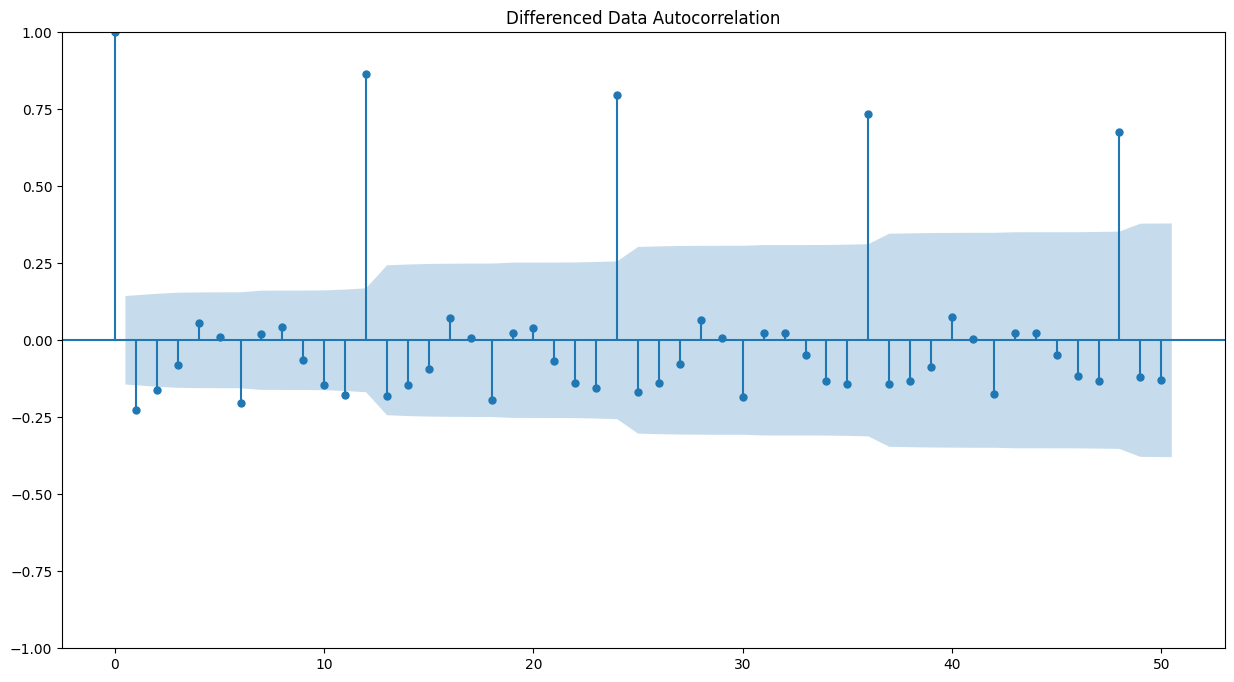

In [127]:
plot_acf(df1['Sparkling'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plt.show()

We see that there can be a seasonality of 12. But from the decompostion at the start we ascertained that visually it looks like the seasonality =12 and thus using the same

##Setting the seasonality as 12 to estimate parametrs using auto SARIMA model.

In [128]:
import itertools
p = q = range(0, 3)
d= range(1,2)
D = range(0,1)
pdq = list(itertools.product(p, d, q))
model_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, D, q))]
print('Examples of some parameter combinations for Model...')
for i in range(1,len(pdq)):
    print('Model: {}{}'.format(pdq[i], model_pdq[i]))

Examples of some parameter combinations for Model...
Model: (0, 1, 1)(0, 0, 1, 12)
Model: (0, 1, 2)(0, 0, 2, 12)
Model: (1, 1, 0)(1, 0, 0, 12)
Model: (1, 1, 1)(1, 0, 1, 12)
Model: (1, 1, 2)(1, 0, 2, 12)
Model: (2, 1, 0)(2, 0, 0, 12)
Model: (2, 1, 1)(2, 0, 1, 12)
Model: (2, 1, 2)(2, 0, 2, 12)


In [129]:
SARIMA_AIC = pd.DataFrame(columns=['param','seasonal', 'AIC'])
SARIMA_AIC

,param,seasonal,AIC


In [130]:
'''import statsmodels.api as sm

for param in pdq:
    for param_seasonal in model_pdq:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train['Sparkling'].values,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

        results_SARIMA = SARIMA_model.fit(maxiter=1000)
        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results_SARIMA.aic))
        SARIMA_AIC = pd.concat({'param':param,'seasonal':param_seasonal ,'AIC': results_SARIMA.aic}, ignore_index=True)'''

"import statsmodels.api as sm\n\nfor param in pdq:\n    for param_seasonal in model_pdq:\n        SARIMA_model = sm.tsa.statespace.SARIMAX(train['Sparkling'].values,\n                                            order=param,\n                                            seasonal_order=param_seasonal,\n                                            enforce_stationarity=False,\n                                            enforce_invertibility=False)\n\n        results_SARIMA = SARIMA_model.fit(maxiter=1000)\n        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results_SARIMA.aic))\n        SARIMA_AIC = pd.concat({'param':param,'seasonal':param_seasonal ,'AIC': results_SARIMA.aic}, ignore_index=True)"

In [131]:
import statsmodels.api as sm
# Loop over ARIMA and seasonal parameter combinations
for param in pdq:
    for param_seasonal in model_pdq:
        # Define the SARIMA model
        SARIMA_model = sm.tsa.statespace.SARIMAX(
            train['Sparkling'].values,
            order=param,
            seasonal_order=param_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        # Fit the SARIMA model
        results_SARIMA = SARIMA_model.fit(maxiter=1000)

        # Print the parameter set and AIC
        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results_SARIMA.aic))

        # Append the results using pd.concat
        new_row = pd.DataFrame([{'param': param, 'seasonal': param_seasonal, 'AIC': results_SARIMA.aic}])
        SARIMA_AIC = pd.concat([SARIMA_AIC, new_row], ignore_index=True)

SARIMA(0, 1, 0)x(0, 0, 0, 12) - AIC:2216.4189020489616
SARIMA(0, 1, 0)x(0, 0, 1, 12) - AIC:1921.5151801498162


<ipython-input-131-83fc9106d3de>:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SARIMA_AIC = pd.concat([SARIMA_AIC, new_row], ignore_index=True)


SARIMA(0, 1, 0)x(0, 0, 2, 12) - AIC:1691.5049017311171
SARIMA(0, 1, 0)x(1, 0, 0, 12) - AIC:1807.295016166554
SARIMA(0, 1, 0)x(1, 0, 1, 12) - AIC:1777.649291387635
SARIMA(0, 1, 0)x(1, 0, 2, 12) - AIC:1601.281534210615
SARIMA(0, 1, 0)x(2, 0, 0, 12) - AIC:1618.9670228363275
SARIMA(0, 1, 0)x(2, 0, 1, 12) - AIC:1617.7268547329593
SARIMA(0, 1, 0)x(2, 0, 2, 12) - AIC:1602.0623659587777
SARIMA(0, 1, 1)x(0, 0, 0, 12) - AIC:2193.281680181415
SARIMA(0, 1, 1)x(0, 0, 1, 12) - AIC:1888.5868794008447
SARIMA(0, 1, 1)x(0, 0, 2, 12) - AIC:1658.7576059582266
SARIMA(0, 1, 1)x(1, 0, 0, 12) - AIC:1768.1554049147571
SARIMA(0, 1, 1)x(1, 0, 1, 12) - AIC:1704.842734071605
SARIMA(0, 1, 1)x(1, 0, 2, 12) - AIC:1536.3191140657548
SARIMA(0, 1, 1)x(2, 0, 0, 12) - AIC:1575.249693559775
SARIMA(0, 1, 1)x(2, 0, 1, 12) - AIC:1564.914938109111
SARIMA(0, 1, 1)x(2, 0, 2, 12) - AIC:1536.4110103186742
SARIMA(0, 1, 2)x(0, 0, 0, 12) - AIC:2143.920900562328
SARIMA(0, 1, 2)x(0, 0, 1, 12) - AIC:1853.6747164387398
SARIMA(0, 1, 2)x(0

In [132]:
SARIMA_AIC.sort_values(by=['AIC']).head()

,param,seasonal,AIC
53,"(1, 1, 2)","(2, 0, 2, 12)",1521.737974
50,"(1, 1, 2)","(1, 0, 2, 12)",1521.949483
80,"(2, 1, 2)","(2, 0, 2, 12)",1523.217832
77,"(2, 1, 2)","(1, 0, 2, 12)",1523.524946
26,"(0, 1, 2)","(2, 0, 2, 12)",1523.707298


In [133]:
import statsmodels.api as sm

auto_SARIMA_12 = sm.tsa.statespace.SARIMAX(train['Sparkling'].values,
                                order=(1, 1, 2),
                                seasonal_order=(1, 0, 2, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_auto_SARIMA_12 = auto_SARIMA_12.fit(maxiter=1000)
print(results_auto_SARIMA_12.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  130
Model:             SARIMAX(1, 1, 2)x(1, 0, 2, 12)   Log Likelihood                -753.975
Date:                            Thu, 05 Dec 2024   AIC                           1521.949
Time:                                    16:18:30   BIC                           1540.324
Sample:                                         0   HQIC                          1529.390
                                            - 130                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6325      0.242     -2.619      0.009      -1.106      -0.159
ma.L1         -0.1412      0.213   

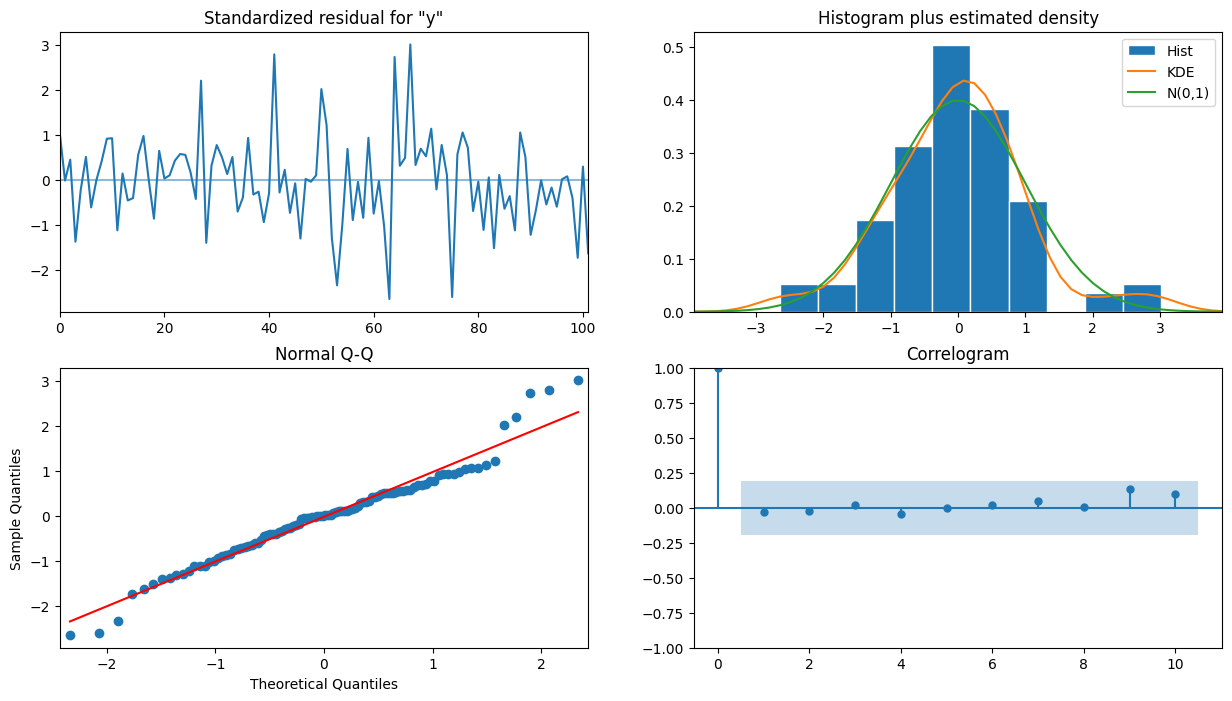

In [134]:
results_auto_SARIMA_12.plot_diagnostics()
plt.show()

From the model diagnostics plot, we can see that all the individual diagnostics plots almost follow the theoretical numbers and thus we cannot develop any pattern from these plots.

##Predict on the Test Set using this model and evaluate the model.

In [135]:
predicted_auto_SARIMA_12 = results_auto_SARIMA_12.get_forecast(steps=len(test))

In [136]:
predicted_auto_SARIMA_12.summary_frame(alpha=0.05).head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,4670.212334,378.770825,3927.835157,5412.589510
1,7180.941291,388.381258,6419.728013,7942.154569
2,1583.587728,388.828613,821.497650,2345.677806
3,1401.311207,391.696295,633.600577,2169.021838
4,1827.408268,391.734758,1059.622252,2595.194285


In [137]:
rmse = mean_squared_error(test['Sparkling'],predicted_auto_SARIMA_12.predicted_mean,squared=False)
print(rmse)

697.0976063790248


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [138]:
temp_resultsDf = pd.DataFrame({'Test RMSE': [rmse]}
                           ,index=['SARIMA(1, 1, 2)(1, 0, 2, 12)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,Test RMSE
RegressionOnTime,1374.550202
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
6pointTrailingMovingAverage,1337.200524
9pointTrailingMovingAverage,1422.653281
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",1597.853999
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232
"Alpha=0.3,Beta=0.5,Gamma=1.0,TripleExponentialSmoothing",1656.729104


In [139]:
print('Sorted by RMSE values on the Test Data:','\n',)
resultsDf.sort_values(by=['Test RMSE'])

Sorted by RMSE values on the Test Data: 



,Test RMSE
"Alpha=0.075,Beta=0.064,Gamma=0.376,TripleExponentialSmoothing",381.657232
"SARIMA(1, 1, 2)(1, 0, 2, 12)",697.097606
2pointTrailingMovingAverage,811.178937
4pointTrailingMovingAverage,1184.213295
"ARIMA(2,1,2)",1325.166743
6pointTrailingMovingAverage,1337.200524
"ARIMA(2, 0, 1)",1338.139904
"Alpha=0.995,SimpleExponentialSmoothing",1362.428949
"Alpha=0.4,SimpleExponentialSmoothing",1363.037803
RegressionOnTime,1374.550202


## Building the most optimum SARIMA model on the Full Data.

In [140]:
full_data_model = sm.tsa.statespace.SARIMAX(df1['Sparkling'],
                                order=(1,1,2),
                                seasonal_order=(1, 0, 2, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_full_data_model = full_data_model.fit(maxiter=1000)
print(results_full_data_model.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Sparkling   No. Observations:                  187
Model:             SARIMAX(1, 1, 2)x(1, 0, 2, 12)   Log Likelihood               -1173.413
Date:                            Thu, 05 Dec 2024   AIC                           2360.827
Time:                                    16:18:34   BIC                           2382.309
Sample:                                01-31-1980   HQIC                          2369.551
                                     - 07-31-1995                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6610      0.242     -2.734      0.006      -1.135      -0.187
ma.L1         -0.2739      0.200   

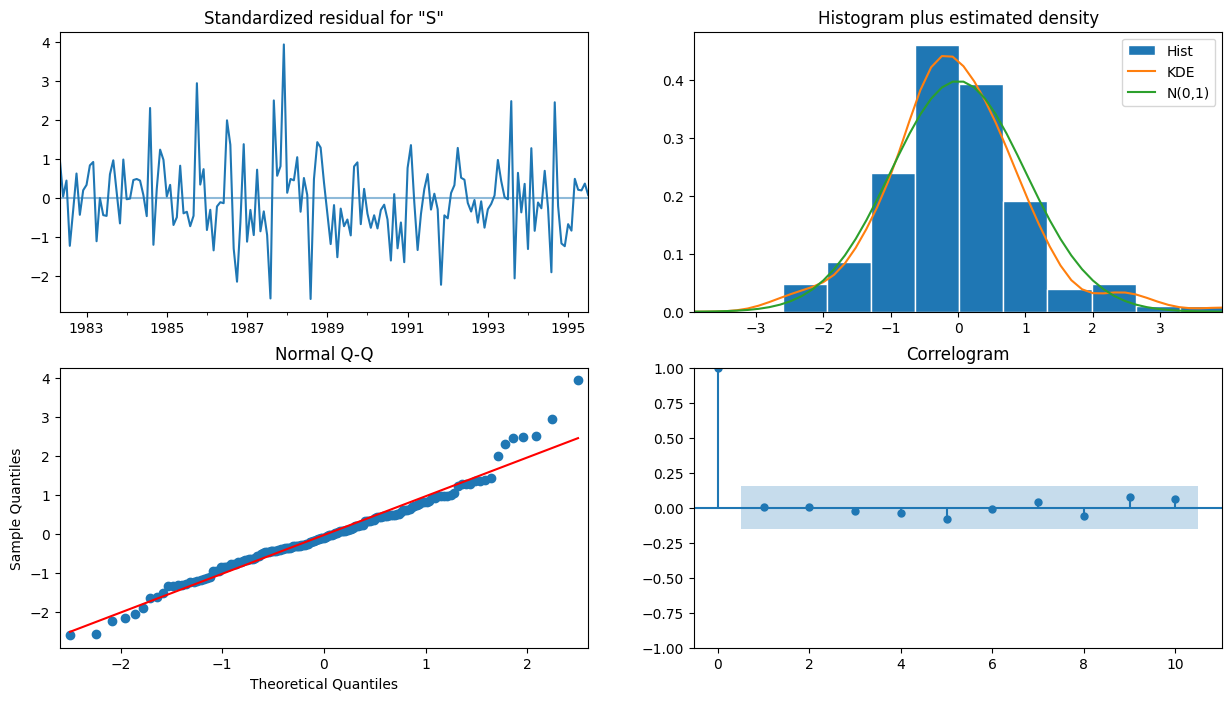

In [141]:
results_full_data_model.plot_diagnostics();

## Evaluate the model on the whole and predict 57 months into the future (till the end of next year).

In [142]:
predicted_manual_SARIMA_12_full_data = results_full_data_model.get_forecast(steps=57)

In [143]:
rmse = mean_squared_error(df1['Sparkling'],results_full_data_model.fittedvalues,squared=False)
print('RMSE of the Full Model',rmse)

RMSE of the Full Model 539.9853944534857


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [144]:
pred_full_manual_SARIMA_date = predicted_manual_SARIMA_12_full_data.summary_frame(alpha=0.05).set_index(pd.date_range(start='1995-08-31',end='2000-05-01', freq='M'))

<ipython-input-144-512522e17873>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pred_full_manual_SARIMA_date = predicted_manual_SARIMA_12_full_data.summary_frame(alpha=0.05).set_index(pd.date_range(start='1995-08-31',end='2000-05-01', freq='M'))


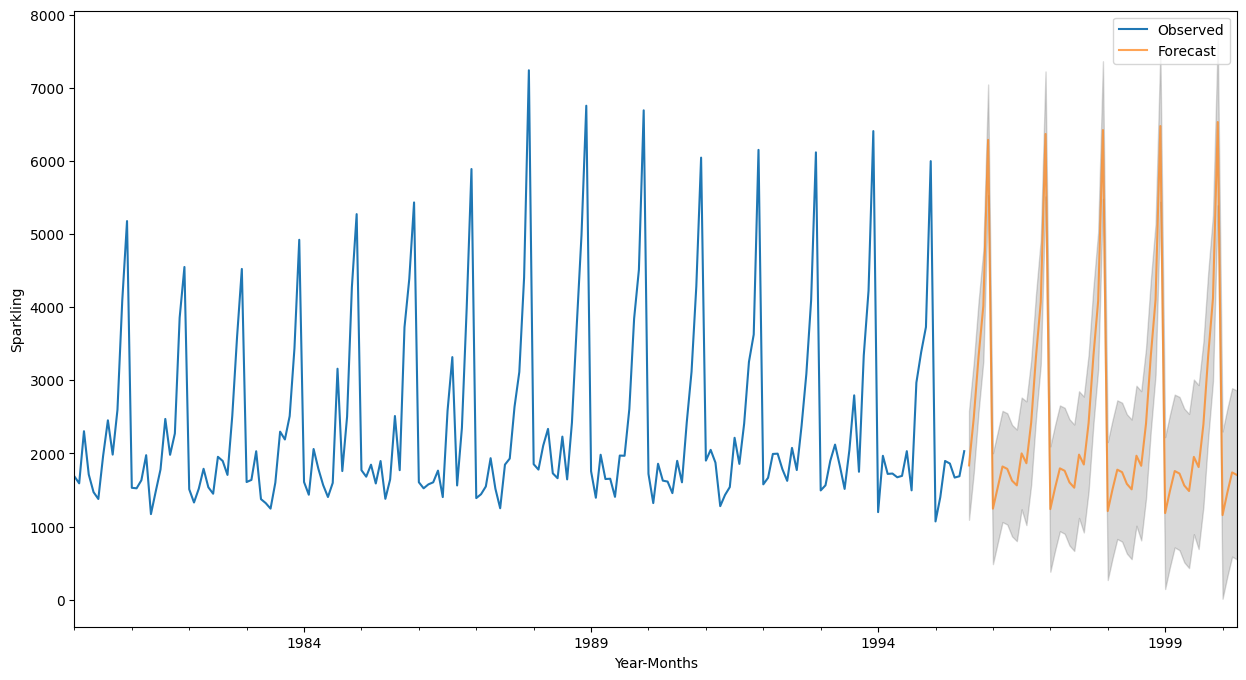

In [145]:
# plot the forecast along with the confidence band

axis = df1['Sparkling'].plot(label='Observed')
pred_full_manual_SARIMA_date['mean'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(pred_full_manual_SARIMA_date.index, pred_full_manual_SARIMA_date['mean_ci_lower'],
                  pred_full_manual_SARIMA_date['mean_ci_upper'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.show()